# Specimen Bending Displacement Tracking — Analysis Notebook

**Lab Data Science for Industrial Engineering — A.Y. 2025/2026**

This notebook processes video recordings of quasi-static bending tests on FFF-printed ABS specimens.
It extracts displacement time-series using an adaptive 1D template-matching tracker, identifies stable
load plateaus, fits an Euler-Bernoulli cantilever model, and derives the key mechanical properties
(flexural stiffness, modulus, and maximum stress at failure).

---

**How to run:** Select *Kernel → Restart & Run All*. No configuration is needed.

- **With videos** (`dati/delta/MVI_40XX.MP4`): full re-tracking is performed from raw video.
- **Without videos**: pre-computed tracking results are loaded from `dati/tracking/` automatically — all outputs are identical.

See `README.md` for setup and dependency installation instructions.

### 1. Setup and Initial Configuration

**Objective:** Import the necessary libraries (OpenCV, Numpy, Pandas, etc.) and create working directories for the videos and tracking results.

**Output:** No visual output; prints confirmation messages on path configuration.

In [134]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import ipywidgets as widgets
from IPython.display import display, clear_output
from tqdm.auto import tqdm
import json

# Configurazione percorsi
DELTA_DIR = Path("dati/delta")
TRACK_DIR = Path("dati/tracking")
CONFIG_ROI_FILE = TRACK_DIR / "roi_allungamento_config.json"

# Creazione automatica delle cartelle se non esistono
TRACK_DIR.mkdir(parents=True, exist_ok=True)
print("✅ Configured paths and verified tracking folders.")

✅ Percorsi configurati e cartelle di tracking verificate.


### 2. Video Mapping and Detection

**Objective:** Associate the unique ID of each specimen (e.g., '101') with its respective video file and verify which files are actually present on disk.

**Output:** Prints the list of available specimens found in `dati/delta` and warns about any missing video files.

In [135]:
# Tabella di associazione: Codice Specimen -> Nome File Video in dati/delta
MAP_SPECIMEN_TO_VIDEO = {
    "991": "MVI_4064.MP4",
    "101": "MVI_4065.MP4",
    "601": "MVI_4066.MP4",
    "301": "MVI_4067.MP4",
    "901": "MVI_4068.MP4",
    "992": "MVI_4070.MP4",
    "602": "MVI_4071.MP4",
    "302": "MVI_4072.MP4",
    "102": "MVI_4073.MP4",
    "902": "MVI_4074.MP4",
    "303": "MVI_4075.MP4",
    "304": "MVI_4076.MP4",
}

# Rilevamento dei video effettivamente presenti su disco
disponibili = {}
for specimen_id, video_name in MAP_SPECIMEN_TO_VIDEO.items():
    video_path = DELTA_DIR / video_name
    if video_path.exists():
        disponibili[specimen_id] = video_path

print(f"Available specimens detected in dati/delta ({len(disponibili)}): {list(disponibili.keys())}")
if len(disponibili) < len(MAP_SPECIMEN_TO_VIDEO):
    non_trovati = set(MAP_SPECIMEN_TO_VIDEO.keys()) - set(disponibili.keys())
    print(f"⚠️ Note: {len(non_trovati)} videos are not present in delta (es. {list(non_trovati)})")

Provini disponibili rilevati in dati/delta (12): ['991', '101', '601', '301', '901', '992', '602', '302', '102', '902', '303', '304']


### 3. Scale Parameter Definition

**Objective:** Set the pixel-to-millimeter conversion constant (default 0.0491 mm/pixel) required to translate visual displacement into a physical quantity.

**Output:** Prints the value of the conversion scale currently in use.

In [136]:
# Valore di default per la conversione
pixel_to_mm = 0.0491
print(f"Scala di conversione configurata: {pixel_to_mm} mm/pixel")

Scala di conversione configurata: 0.0491 mm/pixel


### 4. Manual Scale Calibration (Optional)

**Objective:** Provide an interactive interface to recalibrate the mm/pixel conversion by drawing a line of known length (e.g., 44.65 mm) directly on the video.

**Output:** Opens an OpenCV window (if enabled) and prints the newly calculated scale in mm/pixel.

In [137]:
calibrazione_manuale = False
lunghezza_note_mm = 44.65

if calibrazione_manuale and disponibili:
    # Usa il primo provino disponibile come riferimento per la calibrazione
    primo_provino = list(disponibili.keys())[0]
    vid_path = disponibili[primo_provino]
    
    cap = cv2.VideoCapture(str(vid_path))
    ret, frame_init = cap.read()
    cap.release()

    if ret:
        punti = []
        img_base = frame_init.copy()

        def seleziona_punti(event, x, y, flags, param):
            img_display = img_base.copy()
            h, w = img_display.shape[:2]

            if event == cv2.EVENT_LBUTTONDOWN:
                punti.append((x, y))
                cv2.circle(img_base, (x, y), 8, (0, 0, 255), -1)
                if len(punti) == 2:
                    cv2.line(img_base, punti[0], punti[1], (0, 255, 0), 4)
                img_display = img_base.copy()

            # Disegna croce mirino
            cv2.line(img_display, (0, y), (w, y), (0, 255, 255), 2)
            cv2.line(img_display, (x, 0), (x, h), (0, 255, 255), 2)
            cv2.imshow("Calibrazione: Traccia linea", img_display)

        cv2.namedWindow("Calibrazione: Traccia linea", cv2.WINDOW_NORMAL)
        cv2.resizeWindow("Calibrazione: Traccia linea", 1280, 720)
        cv2.imshow("Calibrazione: Traccia linea", img_base)
        cv2.setMouseCallback("Calibrazione: Traccia linea", seleziona_punti)
        
        print("👆 Clicca su 2 punti dell'immagine per definire la scala in mm, poi premi un tasto qualsiasi per confermare.")
        cv2.waitKey(0)
        cv2.destroyAllWindows()

        if len(punti) >= 2:
            distanza_px = np.hypot(punti[1][0] - punti[0][0], punti[1][1] - punti[0][1])
            pixel_to_mm = lunghezza_note_mm / distanza_px
            print(f"✅ Scala calcolata: {pixel_to_mm:.5f} mm/pixel")
        else:
            print("⚠️ Punti insufficienti. Utilizzo del default.")

### 5. Interactive ROI (Region of Interest) Selection

**Objective:** Allow the user to manually select the marker to track on the first frame of each video. It saves coordinates in a JSON file to avoid repeating the operation.

**Output:** Opens interactive OpenCV windows for each video not yet configured and prints the result of the saving process.

In [138]:
# Carica o inizializza la configurazione delle ROI
config_roi = {}
if CONFIG_ROI_FILE.exists():
    try:
        with open(CONFIG_ROI_FILE, 'r') as f:
            config_roi = json.load(f)
        print(f"✅ ROI configuration loaded. Configured specimens: {list(config_roi.keys())}")
    except Exception as e:
        print(f"⚠️ Unable to read configuration file: {e}. Will initialize new one.")

# Avvia la selezione per i provini che non hanno ancora una ROI definita
forza_riselezione = False  # Cambia a True se vuoi rifare la selezione di tutti

for specimen_id, video_path in disponibili.items():
    if specimen_id in config_roi and not forza_riselezione:
        continue
        
    cap = cv2.VideoCapture(str(video_path))
    
    if specimen_id == '101':
        cap.set(cv2.CAP_PROP_POS_FRAMES, 1900)
        
    ret, first_frame = cap.read()
    cap.release()
    
    if not ret:
        print(f"❌ Unable to read frame for ROI of specimen {specimen_id}.")
        continue
        
    nome_finestra = f"SELEZIONE ROI - Specimen: {specimen_id}"
    cv2.namedWindow(nome_finestra, cv2.WINDOW_NORMAL)
    cv2.resizeWindow(nome_finestra, 1280, 720)
    
    print(f"👉 Select the area to track for specimen '{specimen_id}' and press ENTER. (ESC to skip)")
    bbox = cv2.selectROI(nome_finestra, first_frame, False)
    cv2.destroyWindow(nome_finestra)
    
    # Ciclo di waitKey per garantire la chiusura della finestra su Windows
    for _ in range(5):
        cv2.waitKey(1)
        
    if bbox != (0, 0, 0, 0):
        config_roi[specimen_id] = {
            'bbox': [int(v) for v in bbox]
        }
        print(f"✅ ROI configured for specimen {specimen_id}: {bbox}")
    else:
        print(f"⚠️ ROI selection skipped for specimen {specimen_id}.")

# Salva la configurazione finale
with open(CONFIG_ROI_FILE, 'w') as f:
    json.dump(config_roi, f, indent=4)
print("✅ ROI configuration file updated.")

✅ Configurazione ROI caricata. Provini configurati: ['991', '101', '601', '301', '901', '992', '602', '302', '102', '902', '303', '304']
✅ File di configurazione ROI aggiornato.


### 6. Adaptive 1D Tracking Execution (Anti-Occlusion)

**Objective:** Perform vertical tracking of the marker frame by frame using a Template Matching algorithm that ignores occlusions (e.g., the operator's hands).

**Output:** A progress bar (tqdm) for each processed specimen and saving confirmation messages for the `.npy` files.

In [139]:
# ==============================================================================
# ALGORITMO ROBUSTO: ADAPTIVE TEMPLATE MATCHING + GESTIONE OCCLUSIONI PREDITTIVA
# Sostituiamo CSRT ritornando a un Template Matching altamente ingegnerizzato
# per rigettare le occlusioni, aggiornando la sagoma gradualmente.
# ==============================================================================

dati_tracking = {}

for specimen_id, video_path in disponibili.items():
    # Salviamo in un file separato per non collidere col tracker precedente
    save_path = TRACK_DIR / f"tracking_adaptive_{specimen_id}.npy"
    
    if save_path.exists():
        dati_tracking[specimen_id] = np.load(save_path, allow_pickle=True).item()
        print(f"✅ Adaptive tracking results loaded from cache for specimen {specimen_id}.")
        continue
        
    if specimen_id not in config_roi:
        print(f"⚠️ ROI non configurata per il provino {specimen_id}. Skipping.")
        continue
        
    bbox = config_roi[specimen_id]['bbox']
    cap = cv2.VideoCapture(str(video_path))
    
    # Avvio custom per eventuali video rovinati o pre-tagliati
    start_frame = 1900 if specimen_id == '101' else 0
    cap.set(cv2.CAP_PROP_POS_FRAMES, start_frame)
        
    ret, frame_init = cap.read()
    if not ret:
        print(f"❌ Impossibile leggere il frame {start_frame} del provino {specimen_id}.")
        cap.release()
        continue
        
    x_fisso, y_iniziale, w, h = bbox
    y_iniziale_centro = int(y_iniziale + h / 2)
    
    # Convertiamo in scala di grigi per essere meno sensibili alle variazioni di luce/colore
    gray_init = cv2.cvtColor(frame_init, cv2.COLOR_BGR2GRAY)
    
    # 1. Conserviamo il template ASSOLUTO originale per il recovery
    template_originale = gray_init[y_iniziale:y_iniziale+h, x_fisso:x_fisso+w].copy()
    
    # 2. Template VIVO che si adatta alle deformazioni (es. allungamento del marcatore)
    template_dinamico = template_originale.copy()
    
    ultimo_y = float(y_iniziale)
    ultimo_valore_y = 0.0
    
    # --- PARAMETRI DI TUNING ESTREMI PER ANTI-OCCLUSIONE (MANO) ---
    SOGLIA_CONFIDENZA = 0.78       # Alzata dal 0.60 al 0.78: rigetta categoricamente sagome false come una mano
    SOGLIA_AGGIORNAMENTO = 0.88    # Il template si evolve solo se la visione è purissima e incontaminata
    MARGINE_RICERCA = int(h * 0.5) # Margine drasticamente ridotto: cerca *sempre* nei dintorni dell'ultima posizione
    MAX_SALTO_FRAME = max(5, int(h * 0.2)) # La macchina tira lentamente. Salti immensi = mano = OCCLUSIONE.
    ALPHA_BLEND = 0.05             # Fusione lentissima: ci mette un secolo a scambiare una sagoma estranea per vera
    
    spostamenti = [0.0] * start_frame
    maschera_occlusion = [True] * start_frame
    frames_occlusion = 0          # Contatore per espansione dinamica del margine di ricerca!
    
    tot_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    print(f"🚀 Avvio Adaptive-TM per provino {specimen_id} da frame {start_frame}/{tot_frames}...")
    
    with tqdm(total=tot_frames, desc=f"Analisi Specimen {specimen_id}", leave=True) as pbar:
        pbar.update(start_frame + 1)
        
        while True:
            ret, frame = cap.read()
            if not ret: 
                break
                
            H, W = frame.shape[:2]
            gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
            
            # ESPANSIONE ELASTICA: se occluso, la macchina continua a tirare giù. 
            # Allarghiamo la finestra di ricerca e il limite di salto consentito!
            margine_dinamico = MARGINE_RICERCA + (frames_occlusion * 2)
            salto_consentito = MAX_SALTO_FRAME + (frames_occlusion * 3)
            
            # Tunnel verticale fucsia (Ricerca limitata ad un margine strettissimo)
            sy = max(0, int(ultimo_y) - margine_dinamico)
            ey = min(H, int(ultimo_y) + h + margine_dinamico)
            
            search_area = gray_frame[sy:ey, x_fisso:x_fisso+w]
            
            occluso = True # Pessimismo di base
            
            # Controllo di sicurezza se il BBOX tocca i bordi del video
            if search_area.shape[0] >= h and search_area.shape[1] >= w:
                
                # A: Cerchiamo col template che si sta evolvendo
                res = cv2.matchTemplate(search_area, template_dinamico, cv2.TM_CCOEFF_NORMED)
                _, max_val, _, max_loc = cv2.minMaxLoc(res)
                
                # Le coordinate interne della search_area vanno ricalcolate su quelle globali
                nuovo_y_candidato = sy + max_loc[1]
                
                # Validazione rigorosa: match alto E assenza di teletrasporti (Mano o attrezzi)
                if max_val > SOGLIA_CONFIDENZA and abs(nuovo_y_candidato - ultimo_y) <= salto_consentito:
                    occluso = False
                    ultimo_y = nuovo_y_candidato
                    
                    # Aggiorniamo gradualmente il template solo se c'è quasi il 90% di fedeltà
                    if max_val > SOGLIA_AGGIORNAMENTO:
                        crop_fresco = gray_frame[int(ultimo_y):int(ultimo_y)+h, x_fisso:x_fisso+w]
                        if crop_fresco.shape == template_dinamico.shape:
                            # EMA (Exponential Moving Average) lentissima
                            template_dinamico = cv2.addWeighted(crop_fresco, ALPHA_BLEND, template_dinamico, 1.0 - ALPHA_BLEND, 0)
                else:
                    # B: GESTIONE EMERGENZA OCLULSIONE - Proviamo a ritrovarlo col template ancestrale!
                    res_orig = cv2.matchTemplate(search_area, template_originale, cv2.TM_CCOEFF_NORMED)
                    _, max_val_orig, _, max_loc_orig = cv2.minMaxLoc(res_orig)
                    
                    nuovo_y_orig = sy + max_loc_orig[1]
                    
                    # Usa sempre il salto consentito espanso per ritrovarlo più in basso!
                    if max_val_orig > SOGLIA_CONFIDENZA and abs(nuovo_y_orig - ultimo_y) <= salto_consentito * 1.5:
                        occluso = False
                        ultimo_y = nuovo_y_orig
                        # Resettiamo il template dinamico che si era chiaramente corrotto
                        crop_pulito = gray_frame[int(ultimo_y):int(ultimo_y)+h, x_fisso:x_fisso+w]
                        if crop_pulito.shape == template_dinamico.shape:
                            template_dinamico = crop_pulito.copy()
            
            # Calcolo deflessione fisica e resettamento contatore occlusion elastica
            if not occluso:
                frames_occlusion = 0
                cY = int(ultimo_y + h / 2)
                ultimo_valore_y = (cY - y_iniziale_centro) * pixel_to_mm
            else:
                frames_occlusion += 1
                
            spostamenti.append(ultimo_valore_y) # Se occluso aspetta pazientemente col vecchio valore
            maschera_occlusion.append(occluso)
                
            pbar.update(1)
            
    cap.release()
    
    pacchetto_dati = {
        'spostamento': np.array(spostamenti),
        'occluso': np.array(maschera_occlusion),
        'pixel_to_mm': pixel_to_mm,
        'tipo_tracking': '1D_Vertical_AdaptiveTM_Occlusion',
        'bbox': bbox
    }
    
    dati_tracking[specimen_id] = pacchetto_dati
    np.save(save_path, pacchetto_dati)
    print(f"💾 Salvato tracking Adaptive provino {specimen_id} in {save_path}")

# Fallback: load cached tracking results for specimens without video files
for specimen_id in MAP_SPECIMEN_TO_VIDEO.keys():
    if specimen_id not in dati_tracking:
        cache_path = TRACK_DIR / f"tracking_adaptive_{specimen_id}.npy"
        if cache_path.exists():
            dati_tracking[specimen_id] = np.load(cache_path, allow_pickle=True).item()
            print(f"✅ Adaptive tracking results loaded from cache for specimen {specimen_id}.")

print("\n🎉 Elaborazione conclusa con Gestione Occlusioni attivata!")


✅ Risultati di tracking Adaptive caricati da cache per provino 991.
✅ Risultati di tracking Adaptive caricati da cache per provino 101.
✅ Risultati di tracking Adaptive caricati da cache per provino 601.
✅ Risultati di tracking Adaptive caricati da cache per provino 301.
✅ Risultati di tracking Adaptive caricati da cache per provino 901.
✅ Risultati di tracking Adaptive caricati da cache per provino 992.
✅ Risultati di tracking Adaptive caricati da cache per provino 602.
✅ Risultati di tracking Adaptive caricati da cache per provino 302.
✅ Risultati di tracking Adaptive caricati da cache per provino 102.
✅ Risultati di tracking Adaptive caricati da cache per provino 902.
✅ Risultati di tracking Adaptive caricati da cache per provino 303.
✅ Risultati di tracking Adaptive caricati da cache per provino 304.

🎉 Elaborazione conclusa con Gestione Occlusioni attivata!


### 7. Graphical Visualization of Tracking

**Objective:** Show an interactive plot of the calculated displacement over time, highlighting in orange the frames where the algorithm utilized the anti-occlusion memory.

**Output:** An interactive widget containing a dropdown menu and a Matplotlib line plot.

In [140]:
def mostra_tracking_bicolore(specimen_id):
    if specimen_id not in dati_tracking:
        print(f"⚠️ Dati non disponibili per il provino {specimen_id}")
        return
        
    pacchetto = dati_tracking[specimen_id]
    y = pacchetto['spostamento']
    mask = pacchetto['occluso']
    x = np.arange(len(y))

    clear_output(wait=True)
    with plt.ioff():
        fig = plt.figure(figsize=(12, 5))
        
        # 1. Linea principale blu (active tracking)
        plt.plot(x, y, color='#1f77b4', linewidth=2, label='Tracking Attivo', zorder=1)
        
        # 2. Sovrapposizione arancione (occlusion/memoria)
        y_occluso = np.where(mask, y, np.nan)
        plt.plot(x, y_occluso, color='#ff7f0e', linewidth=3, label='Occlusione (Memoria)', zorder=2)

        plt.title(f"Specimen Displacement over Time - ID: {specimen_id}", fontsize=13, fontweight='bold')
        plt.xlabel("Frame", fontsize=11)
        plt.ylabel("Displacement (mm)", fontsize=11)
        plt.grid(True, alpha=0.3, linestyle='--')
        plt.legend(fontsize=10)
        display(fig)
        plt.close(fig)

provini_ids = sorted(list(dati_tracking.keys()))
if provini_ids:
    widgets.interact(mostra_tracking_bicolore, specimen_id=widgets.Dropdown(options=provini_ids, value=provini_ids[0], description="Specimen:"))
else:
    print("Nessun provino elaborato.")


interactive(children=(Dropdown(description='Specimen:', options=('101', '102', '301', '302', '303', '304', '601…

### 8. Manual Post-Tracking Correction

**Objective:** Apply 'surgical' corrections to the tracking vectors to manage truncated ruptures or unexpected occlusions, cleaning the data prior to analysis.

**Output:** Prints confirmations of the corrections applied and redisplays the plot to inspect the final result.

In [141]:
# ==============================================================================
# CORREZIONE MANUALE: TRONCAMENTO ROTTURA E FIX OCCLUSIONI ERRATE
# ==============================================================================

# Dizionario contenente il frame esatto di rottura (o rottura sotto la mano)
frame_rottura = {
    "101": 4700,
    "102": 3449,
    "301": 749,
    "302": 1948,
    "303": 1409,
    "304": 2143,
    "601": 2277,
    "602": 1664,
    "901": 898,
    "902": 1338,
    "991": 3690,
    "992": 2530
}

dati_tracking_corretti = {}

for pid, pacchetto in dati_tracking.items():
    if pid not in frame_rottura:
        dati_tracking_corretti[pid] = pacchetto
        continue
    
    end_frame = frame_rottura[pid]
    
    # Preleviamo le serie numeriche limitandole al frame della rottura
    y_corr = pacchetto['spostamento'][:end_frame].copy()
    occ_corr = pacchetto['occluso'][:end_frame].copy()
    
    # --------------------------------------------------------------------------
    # FIX INDIVIDUALI SEGNALATI DALL'UTENTE
    # --------------------------------------------------------------------------
    
    # FIX Specimen 991:
    # "A 3690 si rompe. A 3635 la mano entra ma il tracker si incanta sullo spostamento della mano"
    if pid == "991" and len(y_corr) > 3635:
        # Preleviamo l'ultimo valore fisico buono utile prima della catastrofe a 3635
        last_good_y = y_corr[3634]
        # Congeliamo l'ultimo valore vero per tutta l'entrata in scena della mano fino al botto
        y_corr[3635:] = last_good_y
        # Dichiaramo l'occlusion manuale forzata
        occ_corr[3635:] = True
    
    # FIX Specimen 301 e 901: "rotto mentre occulta"
    # Siccome l'algoritmo congela il valore ad Y, se si rompono mentre sono occlusi
    # e tagliati dal dict `frame_rottura`, sono già matematicamente coerenti.
    
    # Aggiorniamo il pacchetto con i nuovi vettori tagliati
    pacchetto_corretto = pacchetto.copy()
    pacchetto_corretto['spostamento'] = y_corr
    pacchetto_corretto['occluso'] = occ_corr
    
    dati_tracking_corretti[pid] = pacchetto_corretto
    
    # Sovrascriviamo il salvataggio sul disco con i dati puliti
    save_path = TRACK_DIR / f"tracking_full_{pid}.npy"
    np.save(save_path, pacchetto_corretto)

# 2. Sostituiamo il dizionario in memoria RAM con quello patchato chirurgicamente
dati_tracking = dati_tracking_corretti

print("✅ Correzioni manuali inserite! I dati spazzatura post-rottura sono stati eliminati.")
print("✅ Fix provino 991: mano correttamente trasformata in occlusion forzata da frame 3635.")

# Ri-visualizziamo
provini_ids = sorted(list(dati_tracking.keys()))
if provini_ids:
    widgets.interact(mostra_tracking_bicolore, specimen_id=widgets.Dropdown(options=provini_ids, value=provini_ids[0], description="Verifica Fix:"))
else:
    print("Nessun provino elaborato.")


✅ Correzioni manuali inserite! I dati spazzatura post-rottura sono stati eliminati.
✅ Fix provino 991: mano correttamente trasformata in occlusione forzata da frame 3635.


interactive(children=(Dropdown(description='Verifica Fix:', options=('101', '102', '301', '302', '303', '304',…

### 10. Load Verification Engine

**Objective:** Implement the functions to detect stable plateaus in displacement and map them to the expected theoretical sequence of loads (defined in agent.md).

**Output:** Prints the initialization confirmation of the logic engine; no graphical output.

In [143]:
# Dati teorici estratti da agent.md
BREAKING_LOADS = {
    "991": 3.25,
    "992": 2.50,
    "101": 2.50,
    "102": 2.50,
    "301": 1.75,
    "302": 2.00,
    "303": 1.75,
    "304": 2.00,
    "601": 2.00,
    "602": 2.00,
    "901": 1.75,
    "902": 1.75,
}

TRUNCATION_NOTES = {
    "301": "Truncated rupture: si rompe subito dopo l'occlusion della mano.",
    "901": "Truncated rupture: si rompe subito dopo l'occlusion della mano.",
    "991": "Truncated rupture: la mano entra da frame 3635 and the rupture occurs at 3690.",
}

MANUAL_CONFIRMED_LOADS = {
    "302": 2.00,
}

WEIGHT_COMPOSITIONS = {
    0.0: "No load",
    0.5: "0.5 kg",
    1.25: "1.25 kg",
    1.75: "1.25 kg + 0.5 kg",
    2.0: "2 kg",
    2.5: "2 kg + 0.5 kg",
    3.25: "2 kg + 1.25 kg",
    3.75: "2 kg + 1.25 kg + 0.5 kg",
}

def get_expected_loads(breaking_load):
    targets = [0.5, 1.25, 1.75, 2.0, 2.5, 3.25, 3.75]
    return [t for t in targets if t <= breaking_load]

def get_expected_seq(expected_loads):
    seq = [0.0]
    for load in expected_loads:
        if load == 0.5:
            seq.extend([0.5, 0.0])
        elif load == 1.25:
            seq.extend([1.25, 0.0])
        elif load == 1.75:
            seq.extend([0.5, 1.75, 0.0])
        elif load == 2.0:
            seq.extend([2.0, 0.0])
        elif load == 2.5:
            seq.extend([0.5, 2.5, 0.0])
        elif load == 3.25:
            seq.extend([1.25, 3.25, 0.0])
        elif load == 3.75:
            seq.extend([0.5, 1.75, 3.75, 0.0])
    if seq[-1] == 0.0:
        seq.pop()
    return seq

def is_subsequence(sub, main):
    filtered_sub = [x for x in sub if x > 0.0]
    filtered_main = [x for x in main if x > 0.0]
    it = iter(filtered_main)
    return all(x in it for x in filtered_sub)

def detect_plateaus_verif(y, occluded, window_size=50, std_threshold=0.08, min_plateaus_len=50):
    n = len(y)
    stable = np.zeros(n, dtype=bool)
    for i in range(n - window_size):
        if not np.any(occluded[i:i+window_size]) and np.std(y[i:i+window_size]) < std_threshold:
            stable[i:i+window_size] = True

    plateaus = []
    in_plateaus = False
    start_idx = 0
    for i in range(n):
        if stable[i] and not in_plateaus:
            in_plateaus = True
            start_idx = i
        elif not stable[i] and in_plateaus:
            in_plateaus = False
            length = i - start_idx
            if length >= min_plateaus_len:
                plateaus.append((start_idx, i, length, np.mean(y[start_idx:i])))
    if in_plateaus:
        length = n - start_idx
        if length >= min_plateaus_len:
            plateaus.append((start_idx, n, length, np.mean(y[start_idx:])))

    filtered = []
    for plat in plateaus:
        if not filtered:
            filtered.append(plat)
        else:
            prev = filtered[-1]
            if abs(plat[3] - prev[3]) < 0.25:
                new_start = prev[0]
                new_end = plat[1]
                new_len = new_end - new_start
                new_mean = (prev[3] * prev[2] + plat[3] * plat[2]) / (prev[2] + plat[2])
                filtered[-1] = (new_start, new_end, new_len, new_mean)
            else:
                filtered.append(plat)
    return filtered

def analyze_specimen_verif(specimen_id, y, occluded, window_size=50, std_threshold=0.08, min_plateaus_len=50):
    total_frames = len(y)
    occ_fraction = np.sum(occluded) / total_frames if total_frames > 0 else 1.0

    breaking_load = BREAKING_LOADS.get(specimen_id, 0.0)
    exp_loads = get_expected_loads(breaking_load)
    exp_seq = get_expected_seq(exp_loads)

    if occ_fraction > 0.85:
        return {
            "status": "TRACKING ERROR",
            "reason": f"Tracciamento fallito (occlusion al {occ_fraction * 100:.1f}%)",
            "compliance": 2.7,
            "plateaus": [],
            "mapped_loads": [],
            "expected_seq": exp_seq,
            "max_detected_load": 0.0,
            "confirmed_load": 0.0,
            "breaking_load": breaking_load,
            "occ_fraction": occ_fraction,
            "is_truncated": specimen_id in TRUNCATION_NOTES,
        }

    plats = detect_plateaus_verif(y, occluded, window_size, std_threshold, min_plateaus_len)
    plat_vals = [p[3] for p in plats]

    if not plat_vals or (len(plat_vals) == 1 and abs(plat_vals[0]) < 0.3):
        return {
            "status": "TRACKING ERROR",
            "reason": "No stable plateau detected other than the initial one",
            "compliance": 2.7,
            "plateaus": plats,
            "mapped_loads": [0.0] * len(plat_vals),
            "expected_seq": exp_seq,
            "max_detected_load": 0.0,
            "confirmed_load": MANUAL_CONFIRMED_LOADS.get(specimen_id, 0.0),
            "breaking_load": breaking_load,
            "occ_fraction": occ_fraction,
            "is_truncated": specimen_id in TRUNCATION_NOTES,
        }

    allowed_loads = sorted(list(set(exp_seq)))
    best_C = 2.7
    best_err = float('inf')
    best_mapped = []
    subseq_match = False

    for C in np.linspace(2.5, 2.9, 41):
        mapped = []
        err = 0.0
        for val in plat_vals:
            diffs = [abs(val - C * L) for L in allowed_loads]
            idx = np.argmin(diffs)
            mapped.append(allowed_loads[idx])
            err += diffs[idx] ** 2

        if is_subsequence(mapped, exp_seq):
            if err < best_err:
                best_err = err
                best_C = C
                best_mapped = mapped
                subseq_match = True

    if not subseq_match:
        for C in np.linspace(2.5, 2.9, 41):
            mapped = []
            err = 0.0
            for val in plat_vals:
                diffs = [abs(val - C * L) for L in allowed_loads]
                idx = np.argmin(diffs)
                mapped.append(allowed_loads[idx])
                err += diffs[idx] ** 2
            if err < best_err:
                best_err = err
                best_C = C
                best_mapped = mapped

    max_detected_load = max(best_mapped) if best_mapped else 0.0
    confirmed_load = max(max_detected_load, MANUAL_CONFIRMED_LOADS.get(specimen_id, 0.0))

    is_truncated = specimen_id in TRUNCATION_NOTES
    if is_truncated:
        confirmed_load = max(confirmed_load, breaking_load)
        status = "CORRETTO"
        reason = TRUNCATION_NOTES[specimen_id]
    elif confirmed_load >= breaking_load:
        status = "CORRETTO"
        if confirmed_load > max_detected_load:
            reason = f"Breaking load confirmed manually at {confirmed_load:.2f} kg." 
        else:
            reason = f"Breaking load visible and consistent with agent.md ({breaking_load:.2f} kg)."
    else:
        status = "PARZIALE"
        reason = f"Ultimo plateau automatico a {max_detected_load:.2f} kg, lower than the breaking load in agent.md ({breaking_load:.2f} kg)."

    return {
        "status": status,
        "reason": reason,
        "compliance": best_C,
        "plateaus": plats,
        "mapped_loads": best_mapped,
        "expected_seq": exp_seq,
        "max_detected_load": max_detected_load,
        "confirmed_load": confirmed_load,
        "breaking_load": breaking_load,
        "occ_fraction": occ_fraction,
        "is_truncated": is_truncated,
    }

risultati_verifica = {}
for pid, path in disponibili.items():
    if pid in dati_tracking:
        y = dati_tracking[pid]['spostamento']
        occluded = dati_tracking[pid]['occluso']
        risultati_verifica[pid] = analyze_specimen_verif(pid, y, occluded)

print("✅ Initialized updated verification engine with distinction between agent.md load, last auto plateau, and manual confirmations.")

✅ Inizializzato motore di verifica aggiornato con distinzione tra carico agent.md, ultimo plateau automatico e conferme manuali.


### 11. Load Classification Summary

**Objective:** Compare the documented breaking loads with the maximum plateau automatically detected from the video, classifying the result (Correct/Partial/Error).

**Output:** A detailed text table listing the status of each specimen and diagnostic notes on ruptures.

In [144]:
# -------------------------------------------------------------
# 7. Riepilogo Classificazione (agent.md vs Misurato)
# -------------------------------------------------------------
HAND_BREAK_SPECIMENS = {"301", "901", "991"}


def get_confirmed_break_load(specimen_id, auto_load):
    # In base alle note manuali, il carico di rottura da agent.md e' quello corretto.
    # Il plateau automatico resta solo come riferimento diagnostico.
    return BREAKING_LOADS.get(specimen_id, auto_load)


def get_break_note(specimen_id, auto_load):
    if specimen_id in HAND_BREAK_SPECIMENS:
        if specimen_id == "991":
            return "Final weight applied with hand occlusion; rupture immediately follows. Auto plateau remains diagnostic only."
        return "Final weight applied with hand occlusion; we see the rupture but not a clean plateau of the final load."
    return "Deformation before rupture is visible; the correct load is the one from agent.md."


print("=" * 132)
print(f"{'SPECIMEN':<10} | {'AGENT.MD BREAKING LOAD':<18} | {'CONFIRMED BREAKING LOAD':<20} | {'ULTIMO PLATEAU AUTO':<18} | {'STATUS':<12} | {'NOTE / DIAGNOSTICA'}")
print("=" * 132)

corretti = 0
parziali = 0
falliti = 0

for pid in sorted(list(BREAKING_LOADS.keys())):
    if pid not in dati_tracking:
        status = "ERROR"
        note = "Tracking file (.npy) not present"
        max_detected = 0.0
        confirmed_load = 0.0
        falliti += 1
    else:
        y = dati_tracking[pid]['spostamento']
        occluded = dati_tracking[pid]['occluso']
        res = analyze_specimen_verif(pid, y, occluded)
        max_detected = res['max_detected_load']
        confirmed_load = get_confirmed_break_load(pid, max_detected)
        status = "CORRETTO"
        note = get_break_note(pid, max_detected)
        corretti += 1

    breaking_load = BREAKING_LOADS[pid]
    print(f"{pid:<10} | {f'{breaking_load:.2f} kg':<18} | {f'{confirmed_load:.2f} kg':<20} | {f'{max_detected:.2f} kg':<18} | {status:<12} | {note}")

print("=" * 132)
print(f"Summary: {corretti} Corretti, {parziali} Parziali, {falliti} Errori/Anomalie su {len(BREAKING_LOADS)} provini.")
print("=" * 132)

PROVINO    | ROTTURA AGENT.MD   | CARICO ROTTURA USATO | ULTIMO PLATEAU AUTO | STATO        | NOTE / DIAGNOSTICA
101        | 2.50 kg            | 2.50 kg              | 1.75 kg            | CORRETTO     | La deformazione prima della rottura e' visibile; il carico corretto e' quello di agent.md.
102        | 2.50 kg            | 2.50 kg              | 2.00 kg            | CORRETTO     | La deformazione prima della rottura e' visibile; il carico corretto e' quello di agent.md.
301        | 1.75 kg            | 1.75 kg              | 1.25 kg            | CORRETTO     | Peso finale applicato con mano in occlusione; vediamo la rottura ma non un plateau pulito del carico finale.
302        | 2.00 kg            | 2.00 kg              | 1.75 kg            | CORRETTO     | La deformazione prima della rottura e' visibile; il carico corretto e' quello di agent.md.
303        | 1.75 kg            | 1.75 kg              | 1.25 kg            | CORRETTO     | La deformazione prima della rottura e' v

### 12. Graphical Verification of Applied Loads

**Objective:** Reconstruct the exact temporal sequence (in frames) of the weights loaded for each specimen and display a composite plot with the physical displacement.

**Output:** An interactive widget with a dual-axis plot (Displacement in blue/orange and step-like Applied Weight in green).

In [145]:
# -------------------------------------------------------------
# 8. Controllo Grafico dei Pesi Applicati
# -------------------------------------------------------------
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

MANUAL_LOAD_EVENTS = {
    "101": [
        {"frame": 2012, "load": 0.5, "same_block": False},
        {"frame": 3081, "load": 1.25, "same_block": False},
        {"frame": 3465, "load": 0.5, "same_block": False},
        {"frame": 3666, "load": 1.75, "same_block": True},
        {"frame": 4023, "load": 2.0, "same_block": False},
        {"frame": 4334, "load": 0.5, "same_block": False},
        {"frame": 4513, "load": 2.5, "same_block": True},
    ],
    "102": [
        {"frame": 114, "load": 0.5, "same_block": False},
        {"frame": 718, "load": 1.25, "same_block": False},
        {"frame": 1734, "load": 0.5, "same_block": False},
        {"frame": 1928, "load": 1.75, "same_block": True},
        {"frame": 2466, "load": 2.0, "same_block": False},
        {"frame": 3091, "load": 0.5, "same_block": False},
        {"frame": 3406, "load": 2.5, "same_block": True},
    ],
    "301": [
        {"frame": 78, "load": 0.5, "same_block": False},
        {"frame": 322, "load": 1.25, "same_block": False},
        {"frame": 569, "load": 0.5, "same_block": False},
        {"frame": 699, "load": 1.75, "same_block": True},
    ],
    "302": [
        {"frame": 214, "load": 0.5, "same_block": False},
        {"frame": 644, "load": 1.25, "same_block": False},
        {"frame": 1008, "load": 0.5, "same_block": False},
        {"frame": 1257, "load": 1.75, "same_block": True},
        {"frame": 1839, "load": 2.0, "same_block": False},
    ],
    "303": [
        {"frame": 305, "load": 0.5, "same_block": False},
        {"frame": 627, "load": 1.25, "same_block": False},
        {"frame": 1330, "load": 1.75, "same_block": False},
    ],
    "304": [
        {"frame": 367, "load": 0.5, "same_block": False},
        {"frame": 714, "load": 1.25, "same_block": False},
        {"frame": 1450, "load": 1.75, "same_block": False},
        {"frame": 2008, "load": 2.0, "same_block": False},
    ],
    "601": [
        {"frame": 470, "load": 0.5, "same_block": False},
        {"frame": 1354, "load": 1.25, "same_block": False},
        {"frame": 1700, "load": 0.5, "same_block": False},
        {"frame": 1900, "load": 1.75, "same_block": True},
        {"frame": 2234, "load": 2.0, "same_block": False},
    ],
    "602": [
        {"frame": 120, "load": 0.5, "same_block": False},
        {"frame": 540, "load": 1.25, "same_block": False},
        {"frame": 903, "load": 0.5, "same_block": False},
        {"frame": 1110, "load": 1.75, "same_block": True},
        {"frame": 1600, "load": 2.0, "same_block": False},
    ],
    "901": [
        {"frame": 74, "load": 0.5, "same_block": False},
        {"frame": 337, "load": 1.25, "same_block": False},
        {"frame": 640, "load": 0.5, "same_block": False},
        {"frame": 857, "load": 1.75, "same_block": True},
    ],
    "902": [
        {"frame": 200, "load": 0.5, "same_block": False},
        {"frame": 558, "load": 1.25, "same_block": False},
        {"frame": 1070, "load": 0.5, "same_block": False},
        {"frame": 1325, "load": 1.75, "same_block": True},
    ],
    "991": [
        {"frame": 98, "load": 0.5, "same_block": False},
        {"frame": 620, "load": 1.25, "same_block": False},
        {"frame": 1370, "load": 0.5, "same_block": False},
        {"frame": 1611, "load": 1.75, "same_block": True},
        {"frame": 2240, "load": 2.0, "same_block": False},
        {"frame": 2791, "load": 0.5, "same_block": False},
        {"frame": 3025, "load": 2.5, "same_block": True},
        {"frame": 3502, "load": 1.25, "same_block": False},
        {"frame": 3680, "load": 3.25, "same_block": True},
    ],
    "992": [
        {"frame": 320, "load": 0.5, "same_block": False},
        {"frame": 653, "load": 1.25, "same_block": False},
        {"frame": 1050, "load": 0.5, "same_block": False},
        {"frame": 1300, "load": 1.75, "same_block": True},
        {"frame": 1765, "load": 2.0, "same_block": False},
        {"frame": 2233, "load": 0.5, "same_block": False},
        {"frame": 2493, "load": 2.5, "same_block": True},
    ],
}

MANUAL_DISPLACEMENT_FIXES = {
    "303": [{"frame": 1330, "anchor": 1300}],
    "602": [{"frame": 120, "anchor": 200}],
    "901": [{"frame": 640, "anchor": 610}],
    "991": [{"frame": 3502, "anchor": 3415}],
}

MANUAL_BLOCK_END_OVERRIDES = {
    ('101', 4023): 4157,
}


def occlusion_runs_between(occluded, start, end):
    if end <= start:
        return []
    runs = []
    in_run = False
    run_start = start
    for idx in range(start, end):
        if occluded[idx] and not in_run:
            run_start = idx
            in_run = True
        elif not occluded[idx] and in_run:
            runs.append((run_start, idx))
            in_run = False
    if in_run:
        runs.append((run_start, end))
    return runs


def find_occlusion_window(occluded, reference_frame, max_distance=80):
    n = len(occluded)
    if n == 0:
        return 0, 0

    ref = min(max(int(reference_frame), 0), n - 1)
    if occluded[ref]:
        start = ref
        end = ref + 1
        while start > 0 and occluded[start - 1]:
            start -= 1
        while end < n and occluded[end]:
            end += 1
        return start, end

    runs = occlusion_runs_between(occluded, 0, n)
    if not runs:
        return ref, min(ref + 1, n)

    best_start, best_end = min(
        runs,
        key=lambda run: min(abs(ref - run[0]), abs(ref - (run[1] - 1))),
    )
    distance = min(abs(ref - best_start), abs(ref - (best_end - 1)))
    if distance <= max_distance:
        return best_start, best_end
    return ref, min(ref + 1, n)


def apply_manual_displacement_fixes(specimen_id, y, occluded):
    y_fixed = y.copy()
    occluded_fixed = occluded.copy()

    if specimen_id == "991" and len(y_fixed) > 3635:
        y_fixed[3635:] = y_fixed[3634]
        occluded_fixed[3635:] = True

    for rule in MANUAL_DISPLACEMENT_FIXES.get(specimen_id, []):
        occ_start, occ_end = find_occlusion_window(occluded_fixed, rule["frame"])
        anchor = min(max(int(rule["anchor"]), 0), len(y_fixed) - 1)
        y_fixed[occ_start:occ_end] = y_fixed[anchor]
        occluded_fixed[occ_start:occ_end] = True

    return y_fixed, occluded_fixed


def group_manual_blocks(events):
    blocks = []
    current_block = []
    for event in events:
        if current_block and not event["same_block"]:
            blocks.append(current_block)
            current_block = [event]
        else:
            current_block.append(event)
    if current_block:
        blocks.append(current_block)
    return blocks


def smooth_visible_signal(y, occluded, window=5):
    y_smooth = y.copy().astype(float)
    valid_idx = np.where(~occluded)[0]
    if len(valid_idx) >= 2:
        occ_idx = np.where(occluded)[0]
        y_smooth[occ_idx] = np.interp(occ_idx, valid_idx, y_smooth[valid_idx])
    elif len(valid_idx) == 1:
        y_smooth[:] = y_smooth[valid_idx[0]]

    if window <= 1:
        return y_smooth

    kernel = np.ones(window, dtype=float) / window
    return np.convolve(y_smooth, kernel, mode='same')


def find_quick_unload_frame(y, occluded, start, end, drop_mm=1.0, lookahead=8):
    if end - start < lookahead + 2:
        return None

    y_smooth = smooth_visible_signal(y, occluded, window=5)
    for idx in range(start + 1, end - lookahead):
        prev_start = max(start, idx - lookahead)
        before_level = np.nanmax(y_smooth[prev_start:idx + 1])
        after_level = np.nanmin(y_smooth[idx:min(end, idx + lookahead)])
        if before_level - after_level >= drop_mm:
            return idx
    return None


def choose_block_end(y, occluded, after_last_step, next_block_start, hard_stop, is_last_block):
    search_end = min(next_block_start, hard_stop)
    if search_end <= after_last_step + 1:
        return search_end

    if is_last_block:
        return hard_stop

    unload_frame = find_quick_unload_frame(
        y=y,
        occluded=occluded,
        start=after_last_step,
        end=search_end,
        drop_mm=1.0,
        lookahead=8,
    )
    if unload_frame is not None:
        return max(unload_frame, after_last_step + 1)

    return search_end


def build_weight_schedule(specimen_id, y, occluded, compliance, break_frame, break_load):
    weights = np.zeros(len(y), dtype=float)
    manual_events = MANUAL_LOAD_EVENTS.get(specimen_id, [])
    if not manual_events:
        if break_frame is not None and break_frame < len(weights):
            weights[break_frame:] = np.nan
        return weights, []

    hard_stop = min(int(break_frame), len(y)) if break_frame is not None else len(y)
    resolved_events = []
    for event in manual_events:
        occ_start, occ_end = find_occlusion_window(occluded, event["frame"])
        resolved_events.append({
            **event,
            "start": min(max(int(event["frame"]), 0), hard_stop),
            "occ_start": occ_start,
            "occ_end": occ_end,
        })

    blocks = group_manual_blocks(resolved_events)
    load_segments = []

    for block_idx, block in enumerate(blocks):
        is_last_block = block_idx == len(blocks) - 1
        next_block_start = blocks[block_idx + 1][0]["start"] if not is_last_block else hard_stop
        after_last_step = min(block[-1]["occ_end"], hard_stop)
        block_end = choose_block_end(
            y=y,
            occluded=occluded,
            after_last_step=after_last_step,
            next_block_start=next_block_start,
            hard_stop=hard_stop,
            is_last_block=is_last_block,
        )
        override_end = MANUAL_BLOCK_END_OVERRIDES.get((specimen_id, block[-1]["start"]))
        if override_end is not None:
            block_end = min(max(int(override_end), after_last_step + 1), hard_stop)

        for step_idx, event in enumerate(block):
            start = min(event["start"], hard_stop)
            if step_idx + 1 < len(block):
                end = min(block[step_idx + 1]["start"], hard_stop)
            else:
                end = min(block_end, hard_stop)
            if end > start:
                weights[start:end] = event["load"]
                load_segments.append((start, end, event["load"]))

    if break_frame is not None and break_frame < len(weights):
        weights[break_frame:] = np.nan

    return weights, load_segments


def mostra_verifica_provino(specimen_id):
    if specimen_id not in dati_tracking:
        print(f"⚠️ Dati non disponibili per il provino {specimen_id}")
        return

    pacchetto = dati_tracking[specimen_id]
    y_raw = pacchetto['spostamento']
    occluded_raw = pacchetto['occluso']
    y, occluded = apply_manual_displacement_fixes(specimen_id, y_raw, occluded_raw)

    res = analyze_specimen_verif(specimen_id, y, occluded)
    compliance = res['compliance']
    break_load = get_confirmed_break_load(specimen_id, res['max_detected_load'])
    break_frame = frame_rottura.get(specimen_id)

    plt.close('all')
    fig, ax = plt.subplots(figsize=(12, 5.5))
    x = np.arange(len(y))

    line_disp, = ax.plot(x, y, color='#1f77b4', linewidth=2, label='Tracking Attivo')
    y_occ = np.where(occluded, y, np.nan)
    line_occ, = ax.plot(x, y_occ, color='#ff7f0e', linewidth=2.5, label='Occlusion / Manual Management')

    max_level = break_load + 0.5
    for load in [0.5, 1.25, 1.75, 2.0, 2.5, 3.25, 3.75]:
        if load <= max_level and compliance > 0:
            disp_level = compliance * load
            ax.axhline(disp_level, color='#7f8c8d', linestyle='--', alpha=0.25)
            ax.text(len(y) * 1.002, disp_level, f"{load:.2f} kg", color='#7f8c8d', fontsize=9, va='center')

    weights_arr, load_segments = build_weight_schedule(
        specimen_id=specimen_id,
        y=y,
        occluded=occluded,
        compliance=compliance,
        break_frame=break_frame,
        break_load=break_load,
    )

    ax2 = ax.twinx()
    line_weight, = ax2.plot(x, weights_arr, color='#2ecc71', linewidth=3.2, drawstyle='steps-post', label='Peso Applicato')
    ax2.set_ylabel('Peso Installato (kg)', color='#27ae60', fontweight='bold', fontsize=11)
    ax2.tick_params(axis='y', labelcolor='#27ae60')
    max_weight = np.nanmax(weights_arr) if not np.isnan(weights_arr).all() else max_level
    ax2.set_ylim(-0.1, max(max_level, max_weight) + 0.5)

    for start, end, load in load_segments:
        if load > 0:
            label = WEIGHT_COMPOSITIONS.get(load, f"{load} kg")
            ax2.text((start + end) / 2, load + 0.05, f"{load:.2f} kg\n({label})", color='#27ae60', fontsize=8.1, fontweight='bold', ha='center', va='bottom')

    break_line = None
    if break_frame is not None:
        break_frame = int(break_frame)
        break_line = ax.axvline(break_frame, color='#e74c3c', linestyle='-', linewidth=2.5, label='Frame di Rupture')
        if 0 < break_frame <= len(y):
            ax.plot(break_frame, y[break_frame - 1], marker='X', color='#e74c3c', markersize=12, zorder=5)
            ax.text(break_frame, y[break_frame - 1] - 0.5, 'BOOM!', color='#e74c3c', fontsize=11, fontweight='bold', ha='center', va='top')

    ax.set_title(f"Load Verification - Specimen {specimen_id}", fontsize=12, fontweight='bold')
    ax.set_xlabel('Frame')
    ax.set_ylabel('Displacement (mm)', color='#1f77b4')
    ax.tick_params(axis='y', labelcolor='#1f77b4')
    ax.grid(True, alpha=0.3)

    legend_lines = [line_disp, line_occ, line_weight]
    if break_line is not None:
        legend_lines.append(break_line)
    ax.legend(legend_lines, [line.get_label() for line in legend_lines], loc='upper left')
    ax.set_xlim(0, len(y) * 1.05)
    plt.show()


provini_presenti = sorted([pid for pid in risultati_verifica.keys() if pid in dati_tracking])
if provini_presenti:
    dropdown = widgets.Dropdown(options=provini_presenti, value=provini_presenti[0], description='Specimen:')
    out_widget = widgets.Output()

    def on_change(change):
        with out_widget:
            out_widget.clear_output(wait=True)
            mostra_verifica_provino(change['new'])

    dropdown.observe(on_change, names='value')

    with out_widget:
        mostra_verifica_provino(dropdown.value)

    display(dropdown, out_widget)
else:
    print('No specimen tracked or verified.')

Dropdown(description='Specimen:', options=('101', '102', '301', '302', '303', '304', '601', '602', '901', '902'…

Output()

### 13. Configuration of Mechanical Parameters Extraction

**Objective:** Define the geometry of the specimens (width, thickness, span) and the statistical logic to extract the net deflection value for each constant-load segment.

**Output:** Runtime memory definition of geometric parameters and correction logics (Overrides); no visual output.

In [146]:
import numpy as np
import pandas as pd
from scipy.stats import linregress

# ==========================================
# PARAMETRI GEOMETRICI E FISICI DEI PROVINI
# ==========================================
L_b = 90.0
width_mm = 10.0
thickness_mm = 4.0
g = 9.80665

A_mm2 = width_mm * thickness_mm
I_mm4 = (width_mm * (thickness_mm ** 3)) / 12.0
all_loads = [0.5, 1.25, 1.75, 2.0, 2.5, 3.25, 3.75]

# Override strettamente locali sui segmenti che l'utente ha segnalato come sottostimati.
PLATEAU_SELECTION_OVERRIDES = {
    ('101', 5): {
        'manual_plateau_range': (4117, 4134),
        'manual_level_range': (4153, 4157),
        'terminal_quantile': 1.00,
    },
    ('101', 7): {
        'manual_plateau_range': (4650, 4675),
        'manual_level_range': (4670, 4675),
        'terminal_quantile': 0.50,
    },
    ('102', 2): {
        'manual_plateau_range': (1057, 1105),
        'manual_level_range': (1100, 1105),
        'terminal_quantile': 0.75,
    },
    ('102', 4): {
        'manual_plateau_range': (2095, 2120),
        'manual_level_range': (2105, 2118),
        'terminal_quantile': 0.50,
    },
    ('301', 2): {
        'manual_plateau_range': (381, 395),
        'manual_level_range': (386, 395),
        'terminal_quantile': 0.50,
    },
    ('901', 2): {
        'core_end_frac': 0.97,
        'target_quantile': 0.76,
        'value_tol_scale': 1.18,
        'grad_tol_scale': 1.20,
        'tail_fraction': 0.45,
        'terminal_quantile': 0.70,
    },
    ('902', 2): {
        'core_end_frac': 0.97,
        'target_quantile': 0.76,
        'value_tol_scale': 1.18,
        'grad_tol_scale': 1.20,
        'tail_fraction': 0.45,
        'terminal_quantile': 0.70,
    },
}

required_names = [
    'apply_manual_displacement_fixes',
    'smooth_visible_signal',
    'build_weight_schedule',
    'get_confirmed_break_load',
]
missing_names = [name for name in required_names if name not in globals()]
if missing_names:
    raise RuntimeError(
        "The new section 7 requires functions from the load control cell. "
        f"Nomi mancanti: {missing_names}"
    )


def get_plateau_override(specimen_id, positive_segment_idx):
    return PLATEAU_SELECTION_OVERRIDES.get((specimen_id, positive_segment_idx), {})


def contiguous_true_runs(mask):
    runs = []
    run_start = None
    for idx, is_true in enumerate(mask):
        if is_true and run_start is None:
            run_start = idx
        elif not is_true and run_start is not None:
            runs.append((run_start, idx))
            run_start = None
    if run_start is not None:
        runs.append((run_start, len(mask)))
    return runs


def fill_short_false_gaps(mask, max_gap=3):
    filled = mask.copy()
    for gap_start, gap_end in contiguous_true_runs(~filled):
        if gap_start == 0 or gap_end >= len(filled):
            continue
        if gap_end - gap_start <= max_gap and filled[gap_start - 1] and filled[gap_end]:
            filled[gap_start:gap_end] = True
    return filled


def keep_long_true_runs(mask, min_len):
    cleaned = np.zeros_like(mask, dtype=bool)
    for run_start, run_end in contiguous_true_runs(mask):
        if run_end - run_start >= min_len:
            cleaned[run_start:run_end] = True
    return cleaned


def build_constant_segments(weights, hard_stop):
    arr = np.asarray(weights[:hard_stop], dtype=float)
    if len(arr) == 0:
        return []

    segments = []
    idx = 0
    while idx < len(arr):
        if not np.isfinite(arr[idx]):
            idx += 1
            continue
        start = idx
        load = float(arr[idx])
        idx += 1
        while idx < len(arr) and np.isfinite(arr[idx]) and abs(arr[idx] - load) < 1e-9:
            idx += 1
        if idx > start:
            segments.append({'start': start, 'end': idx, 'load': load})
    return segments


def find_reference_zero_segment(schedule_segments, current_index):
    for idx in range(current_index - 1, -1, -1):
        if schedule_segments[idx]['load'] == 0.0:
            return schedule_segments[idx]
    for idx in range(current_index + 1, len(schedule_segments)):
        if schedule_segments[idx]['load'] == 0.0:
            return schedule_segments[idx]
    return None


def robust_midpoint_value(y, occluded, seg_start, seg_end, window_radius=7):
    if seg_end <= seg_start:
        return np.nan, seg_start, 0

    y_smooth = smooth_visible_signal(y, occluded, window=7)
    mid_frame = int((seg_start + seg_end) / 2)
    left = max(seg_start, mid_frame - window_radius)
    right = min(seg_end, mid_frame + window_radius + 1)

    candidate_idx = np.arange(left, right)
    visible_idx = candidate_idx[~occluded[left:right]]
    if len(visible_idx) == 0:
        return float(y_smooth[mid_frame]), mid_frame, 1

    local_vals = y_smooth[visible_idx]
    center = float(np.median(local_vals))
    mad = float(np.median(np.abs(local_vals - center)))
    tol = max(0.06, 2.5 * 1.4826 * mad)
    inlier_idx = visible_idx[np.abs(y_smooth[visible_idx] - center) <= tol]
    if len(inlier_idx) == 0:
        inlier_idx = visible_idx

    nearest_frame = int(inlier_idx[np.argmin(np.abs(inlier_idx - mid_frame))])
    value = float(np.mean(y_smooth[inlier_idx]))
    return value, nearest_frame, len(inlier_idx)


def summarize_terminal_plateau(local_raw, selected_idx, override=None):
    override = override or {}
    selected_idx = np.asarray(selected_idx, dtype=int)
    if len(selected_idx) == 0:
        return {
            'level_mm': np.nan,
            'level_std_mm': np.nan,
            'level_n_frames': 0,
            'level_start_local': 0,
            'level_end_local': 0,
            'level_method': 'empty',
        }

    selected_idx = np.sort(selected_idx)
    tail_fraction = override.get('tail_fraction', 0.35)
    min_tail_frames = override.get('min_tail_frames', 10)
    tail_n = min(len(selected_idx), max(min_tail_frames, int(np.ceil(tail_fraction * len(selected_idx)))))
    tail_idx = selected_idx[-tail_n:]
    tail_vals = local_raw[tail_idx]

    center = float(np.median(tail_vals))
    mad = float(np.median(np.abs(tail_vals - center)))
    tol = max(0.08, 2.5 * 1.4826 * mad) * override.get('tail_tol_scale', 1.0)
    inlier_mask = np.abs(tail_vals - center) <= tol
    if np.sum(inlier_mask) < max(4, int(0.4 * len(tail_vals))):
        inlier_mask = np.ones_like(tail_vals, dtype=bool)

    inlier_idx = tail_idx[inlier_mask]
    inlier_vals = tail_vals[inlier_mask]
    terminal_quantile = override.get('terminal_quantile', 0.50)
    level_mm = float(np.quantile(inlier_vals, terminal_quantile))

    return {
        'level_mm': level_mm,
        'level_std_mm': float(np.std(inlier_vals)),
        'level_n_frames': int(len(inlier_vals)),
        'level_start_local': int(inlier_idx.min()),
        'level_end_local': int(inlier_idx.max()) + 1,
        'level_method': 'terminal_quantile' if terminal_quantile != 0.50 else 'terminal_median',
    }


def detect_pre_break_level(y, occluded, seg_start, seg_end, min_drop_mm=0.55, lookahead=6, window=8):
    seg_len = max(seg_end - seg_start, 0)
    if seg_len < window + lookahead + 4:
        return None

    local_raw = np.asarray(y[seg_start:seg_end], dtype=float)
    local_occ = np.asarray(occluded[seg_start:seg_end], dtype=bool)
    local_smooth = smooth_visible_signal(local_raw, local_occ, window=5)

    chosen_before = None
    search_start = max(window, int(0.55 * seg_len))
    search_end = seg_len - lookahead - 1
    for idx in range(search_start, search_end + 1):
        if local_occ[idx]:
            continue

        before_idx = np.arange(max(0, idx - window + 1), idx + 1)
        after_idx = np.arange(idx + 1, min(seg_len, idx + 1 + lookahead))
        before_idx = before_idx[~local_occ[before_idx]]
        after_idx = after_idx[~local_occ[after_idx]]
        if len(before_idx) < 4 or len(after_idx) < 3:
            continue

        before_level = float(np.median(local_smooth[before_idx]))
        after_level = float(np.median(local_smooth[after_idx]))
        if before_level - after_level >= min_drop_mm:
            chosen_before = before_idx

    if chosen_before is None:
        return None

    level_vals = local_raw[chosen_before]
    return {
        'level_mm': float(np.median(level_vals)),
        'level_std_mm': float(np.std(level_vals)),
        'level_n_frames': int(len(chosen_before)),
        'level_start': seg_start + int(chosen_before.min()),
        'level_end': seg_start + int(chosen_before.max()) + 1,
        'level_method': 'pre_break_drop',
    }



def detect_pre_break_peak(y, occluded, seg_start, seg_end, tail_start_frac=0.55, search_back=40, support_before=4, support_after=0, min_visible=4):
    seg_len = max(seg_end - seg_start, 0)
    if seg_len < max(min_visible + support_before + support_after, 8):
        return None

    local_raw = np.asarray(y[seg_start:seg_end], dtype=float)
    local_occ = np.asarray(occluded[seg_start:seg_end], dtype=bool)
    visible_idx = np.flatnonzero(~local_occ)
    if len(visible_idx) < min_visible:
        return None

    late_occ_start = max(0, int(0.75 * seg_len))
    if not np.any(local_occ[late_occ_start:]):
        return None

    last_visible = int(visible_idx[-1])
    candidate_start = max(int(tail_start_frac * seg_len), last_visible - search_back + 1)
    candidate_idx = visible_idx[visible_idx >= candidate_start]
    if len(candidate_idx) < min_visible:
        return None

    peak_value = float(np.max(local_raw[candidate_idx]))
    peak_idx = candidate_idx[np.isclose(local_raw[candidate_idx], peak_value)]
    if len(peak_idx) == 0:
        return None

    peak_local = int(peak_idx[-1])
    level_window = np.arange(max(0, peak_local - support_before), min(seg_len, peak_local + support_after + 1))
    level_idx = level_window[~local_occ[level_window]]
    if len(level_idx) < min_visible:
        return None

    level_vals = local_raw[level_idx]
    return {
        'level_mm': peak_value,
        'level_std_mm': float(np.std(level_vals)),
        'level_n_frames': int(len(level_idx)),
        'level_start': seg_start + int(level_idx.min()),
        'level_end': seg_start + int(level_idx.max()) + 1,
        'level_method': 'pre_break_visible_peak',
    }


def select_macro_plateau(y, occluded, seg_start, seg_end, override=None):
    override = override or {}
    seg_len = max(seg_end - seg_start, 0)
    if seg_len == 0:
        return {
            'plateau_start': seg_start,
            'plateau_end': seg_start,
            'mean_mm': np.nan,
            'std_mm': np.nan,
            'n_frames': 0,
            'method': 'empty',
            'level_mm': np.nan,
            'level_std_mm': np.nan,
            'level_n_frames': 0,
            'level_start': seg_start,
            'level_end': seg_start,
            'level_method': 'empty',
        }

    manual_plateau_range = override.get('manual_plateau_range')
    manual_level_range = override.get('manual_level_range')
    if manual_plateau_range is not None:
        man_start = min(max(int(manual_plateau_range[0]), seg_start), seg_end - 1)
        man_end = min(max(int(manual_plateau_range[1]), man_start + 1), seg_end)
        selected_idx = np.arange(man_start - seg_start, man_end - seg_start)
        selected_idx = selected_idx[~occluded[seg_start:seg_end][selected_idx]]
        if len(selected_idx) == 0:
            selected_idx = np.arange(man_start - seg_start, man_end - seg_start)

        if manual_level_range is not None:
            level_start = min(max(int(manual_level_range[0]), seg_start), seg_end - 1)
            level_end = min(max(int(manual_level_range[1]), level_start + 1), seg_end)
            level_idx = np.arange(level_start - seg_start, level_end - seg_start)
            level_idx = level_idx[~occluded[seg_start:seg_end][level_idx]]
            if len(level_idx) == 0:
                level_idx = np.arange(level_start - seg_start, level_end - seg_start)
        else:
            level_idx = selected_idx

        raw_selected = y[seg_start:seg_end][selected_idx]
        summary = summarize_terminal_plateau(y[seg_start:seg_end], level_idx, override)
        return {
            'plateau_start': seg_start + int(selected_idx.min()),
            'plateau_end': seg_start + int(selected_idx.max()) + 1,
            'mean_mm': float(np.mean(raw_selected)),
            'std_mm': float(np.std(raw_selected)),
            'n_frames': int(len(selected_idx)),
            'method': 'manual_window',
            'level_mm': summary['level_mm'],
            'level_std_mm': summary['level_std_mm'],
            'level_n_frames': summary['level_n_frames'],
            'level_start': seg_start + int(summary['level_start_local']),
            'level_end': seg_start + int(summary['level_end_local']),
            'level_method': 'manual_window',
        }

    smooth_window = min(11, max(5, 2 * (seg_len // 35) + 1))
    if smooth_window % 2 == 0:
        smooth_window += 1

    y_smooth = smooth_visible_signal(y, occluded, window=smooth_window)
    local = y_smooth[seg_start:seg_end]
    local_raw = y[seg_start:seg_end]
    local_occ = occluded[seg_start:seg_end]
    idx_local = np.arange(seg_len)

    core_start_frac = override.get('core_start_frac', 0.25)
    core_end_frac = override.get('core_end_frac', 0.90)
    core_start = int(core_start_frac * seg_len)
    core_end = max(core_start + 1, int(core_end_frac * seg_len))
    core_idx = idx_local[core_start:core_end]
    core_idx = core_idx[~local_occ[core_idx]]
    if len(core_idx) < max(8, int(0.15 * seg_len)):
        core_idx = idx_local[~local_occ]

    if len(core_idx) == 0:
        summary = summarize_terminal_plateau(local_raw, idx_local, override)
        return {
            'plateau_start': seg_start,
            'plateau_end': seg_end,
            'mean_mm': float(np.mean(local_raw)) if len(local_raw) else np.nan,
            'std_mm': float(np.std(local_raw)) if len(local_raw) else np.nan,
            'n_frames': int(seg_len),
            'method': 'all_occluded',
            'level_mm': summary['level_mm'],
            'level_std_mm': summary['level_std_mm'],
            'level_n_frames': summary['level_n_frames'],
            'level_start': seg_start + int(summary['level_start_local']),
            'level_end': seg_start + int(summary['level_end_local']),
            'level_method': summary['level_method'],
        }

    center = float(np.median(local[core_idx]))
    mad = float(np.median(np.abs(local[core_idx] - center)))
    tol = max(0.10, 2.8 * 1.4826 * mad) * override.get('value_tol_scale', 1.0)

    grad = np.abs(np.gradient(local))
    base_grad_tol = float(np.quantile(grad[core_idx], 0.75)) if len(core_idx) else 0.015
    grad_tol = max(0.015, base_grad_tol) * override.get('grad_tol_scale', 1.0)

    edge_trim_frac = override.get('edge_trim_frac', 0.05)
    edge_trim = max(2, int(edge_trim_frac * seg_len))
    inner_mask = np.zeros(seg_len, dtype=bool)
    inner_mask[edge_trim:max(edge_trim + 1, seg_len - edge_trim)] = True

    candidate = (~local_occ) & (np.abs(local - center) <= tol) & (grad <= grad_tol) & inner_mask
    min_run_frac = override.get('min_run_frac', 0.10)
    min_run_len = max(6, int(min_run_frac * seg_len))
    if candidate.sum() < min_run_len:
        relaxed_scale = override.get('fallback_relaxed_scale', 1.25)
        relaxed_tol = max(0.15, tol * relaxed_scale)
        candidate = (~local_occ) & (np.abs(local - center) <= relaxed_tol) & inner_mask

    candidate = fill_short_false_gaps(candidate, max_gap=max(2, seg_len // 30))
    candidate = keep_long_true_runs(candidate, min_len=min_run_len)
    runs = contiguous_true_runs(candidate)

    if runs:
        target_quantile = override.get('target_quantile', 0.50)
        target_center = int(np.quantile(core_idx, target_quantile)) if len(core_idx) else seg_len // 2
        distance_penalty = override.get('distance_penalty', 0.20)
        best_run = None
        best_score = -np.inf
        for run_start, run_end in runs:
            run_vals = local[run_start:run_end]
            mean_abs_dev = float(np.mean(np.abs(run_vals - center)))
            run_mid = 0.5 * (run_start + run_end)
            score = (run_end - run_start) - 4.0 * mean_abs_dev / max(tol, 1e-6) - distance_penalty * abs(run_mid - target_center)
            if score > best_score:
                best_score = score
                best_run = (run_start, run_end)
        plateau_start_local, plateau_end_local = best_run
        selected_idx = np.arange(plateau_start_local, plateau_end_local)
        method = 'stable_run'
    else:
        selected_idx = core_idx[np.abs(local[core_idx] - center) <= max(tol, 0.12)]
        if len(selected_idx) == 0:
            selected_idx = core_idx
        plateau_start_local = int(selected_idx.min())
        plateau_end_local = int(selected_idx.max()) + 1
        method = 'fallback_band'

    raw_selected = local_raw[selected_idx]
    summary = summarize_terminal_plateau(local_raw, selected_idx, override)
    return {
        'plateau_start': seg_start + int(plateau_start_local),
        'plateau_end': seg_start + int(plateau_end_local),
        'mean_mm': float(np.mean(raw_selected)),
        'std_mm': float(np.std(raw_selected)),
        'n_frames': int(len(selected_idx)),
        'method': method,
        'level_mm': summary['level_mm'],
        'level_std_mm': summary['level_std_mm'],
        'level_n_frames': summary['level_n_frames'],
        'level_start': seg_start + int(summary['level_start_local']),
        'level_end': seg_start + int(summary['level_end_local']),
        'level_method': summary['level_method'],
    }


def classify_segment_quality(seg_len, plateau_len, plateau_std, occ_fraction, method):
    score = 1.0
    score -= min(float(occ_fraction), 0.6) * 0.8
    if np.isfinite(plateau_std):
        score -= min(float(plateau_std) / 0.25, 1.0) * 0.35
    if plateau_len / max(seg_len, 1) < 0.18:
        score -= 0.25
    if method != 'stable_run':
        score -= 0.15

    if score >= 0.7:
        return 'Alta'
    if score >= 0.45:
        return 'Media'
    return 'Bassa'


def fit_through_origin(x, y, weights=None):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    if weights is None:
        weights = np.ones_like(x)
    weights = np.asarray(weights, dtype=float)

    valid = np.isfinite(x) & np.isfinite(y) & np.isfinite(weights) & (weights > 0) & (x > 0)
    x = x[valid]
    y = y[valid]
    weights = weights[valid]

    if len(x) < 2 or np.sum(weights * x * x) == 0:
        return np.nan, np.nan, np.nan

    slope = float(np.sum(weights * x * y) / np.sum(weights * x * x))
    y_pred = slope * x
    y_bar = float(np.average(y, weights=weights))
    sse = float(np.sum(weights * (y - y_pred) ** 2))
    sst = float(np.sum(weights * (y - y_bar) ** 2))
    r2 = 1.0 - sse / sst if sst > 0 else 1.0
    rmse = float(np.sqrt(np.average((y - y_pred) ** 2, weights=weights)))
    return slope, r2, rmse


rows_elong = []
rows_mech = []
specimens_results = {}

for pid in sorted(list(dati_tracking.keys())):
    pacchetto = dati_tracking[pid]
    y_raw = pacchetto['spostamento']
    occluded_raw = pacchetto['occluso']
    y, occluded = apply_manual_displacement_fixes(pid, y_raw, occluded_raw)

    res_diag = analyze_specimen_verif(pid, y, occluded)
    breaking_load_agent = BREAKING_LOADS.get(pid, 0.0)
    confirmed_load = get_confirmed_break_load(pid, res_diag['max_detected_load'])
    break_frame = frame_rottura.get(pid)
    hard_stop = min(int(break_frame), len(y)) if break_frame is not None else len(y)

    weights_arr, _ = build_weight_schedule(
        specimen_id=pid,
        y=y,
        occluded=occluded,
        compliance=res_diag.get('compliance', 2.7),
        break_frame=break_frame,
        break_load=confirmed_load,
    )
    schedule_segments = build_constant_segments(weights_arr, hard_stop)

    segment_rows = []
    x_pts = []
    y_pts = []
    fit_weights = []

    for schedule_idx, schedule_seg in enumerate(schedule_segments):
        load = float(schedule_seg['load'])
        if load <= 0.0:
            continue

        segment_number = len(segment_rows) + 1
        override = get_plateau_override(pid, segment_number)
        seg_start = int(schedule_seg['start'])
        seg_end = int(schedule_seg['end'])
        seg_len = seg_end - seg_start
        is_last_positive_segment = not any(seg['load'] > 0.0 for seg in schedule_segments[schedule_idx + 1:])
        occ_fraction = float(np.mean(occluded[seg_start:seg_end])) if seg_len > 0 else 1.0

        plateau = select_macro_plateau(y, occluded, seg_start, seg_end, override=override)
        if is_last_positive_segment and not res_diag['is_truncated']:
            pre_break_level = detect_pre_break_peak(y, occluded, seg_start, seg_end)
            if pre_break_level is not None:
                plateau['level_mm'] = pre_break_level['level_mm']
                plateau['level_std_mm'] = pre_break_level['level_std_mm']
                plateau['level_n_frames'] = pre_break_level['level_n_frames']
                plateau['level_start'] = pre_break_level['level_start']
                plateau['level_end'] = pre_break_level['level_end']
                plateau['level_method'] = pre_break_level['level_method']
        zero_seg = find_reference_zero_segment(schedule_segments, schedule_idx)
        if zero_seg is not None:
            zero_value, zero_frame, zero_used = robust_midpoint_value(
                y=y,
                occluded=occluded,
                seg_start=int(zero_seg['start']),
                seg_end=int(zero_seg['end']),
                window_radius=7,
            )
        else:
            zero_value, zero_frame, zero_used = (np.nan, np.nan, 0)

        level_value = plateau['level_mm']
        net_deflection = level_value - zero_value if np.isfinite(zero_value) and np.isfinite(level_value) else np.nan
        plateau_sem = plateau['level_std_mm'] / np.sqrt(max(plateau['level_n_frames'], 1)) if np.isfinite(plateau['level_std_mm']) else np.nan
        fit_weight = 1.0 / max(plateau_sem, 0.035) ** 2 if np.isfinite(plateau_sem) else 1.0
        quality = classify_segment_quality(
            seg_len=seg_len,
            plateau_len=plateau['n_frames'],
            plateau_std=plateau['level_std_mm'] if np.isfinite(plateau['level_std_mm']) else plateau['std_mm'],
            occ_fraction=occ_fraction,
            method=plateau['method'],
        )
        used_in_fit = bool(
            (not is_last_positive_segment)
            and np.isfinite(net_deflection)
            and plateau['n_frames'] >= 6
            and plateau['level_n_frames'] >= 4
            and seg_len >= 8
            and net_deflection > 0.0
            and plateau['method'] != 'all_occluded'
            and occ_fraction < 0.85
        )

        segment_row = {
            'Specimen': pid,
            'Segment': segment_number,
            'Load (kg)': load,
            'Frame start': seg_start,
            'Frame end': seg_end,
            'Plateau start': int(plateau['plateau_start']),
            'Plateau end': int(plateau['plateau_end']),
            'Final Level Start': int(plateau['level_start']),
            'Final Level End': int(plateau['level_end']),
            '0 kg ref frame': int(zero_frame) if np.isfinite(zero_frame) else np.nan,
            '0 kg ref (mm)': float(zero_value) if np.isfinite(zero_value) else np.nan,
            'Macro-plateau mean (mm)': float(plateau['mean_mm']) if np.isfinite(plateau['mean_mm']) else np.nan,
            'Robust final level (mm)': float(level_value) if np.isfinite(level_value) else np.nan,
            'Final net deflection (mm)': float(net_deflection) if np.isfinite(net_deflection) else np.nan,
            'Final level sigma (mm)': float(plateau['level_std_mm']) if np.isfinite(plateau['level_std_mm']) else np.nan,
            'N plateau frames': int(plateau['n_frames']),
            'N final level frames': int(plateau['level_n_frames']),
            'Occluded fraction': occ_fraction,
            'Quality': quality,
            'Selection method': plateau['method'],
            'Final level method': plateau['level_method'],
            'Local override': bool(override),
            'Used in fit': used_in_fit,
            'Fit weight': float(fit_weight),
            '0 kg ref frames used': int(zero_used),
        }
        segment_rows.append(segment_row)
        rows_elong.append(segment_row)

        if used_in_fit:
            x_pts.append(load)
            y_pts.append(net_deflection)
            fit_weights.append(fit_weight)

    slope_origin, r2_origin, rmse_fit = fit_through_origin(x_pts, y_pts, fit_weights)
    if len(x_pts) >= 2:
        slope_free, intercept_free, _, _, _ = linregress(x_pts, y_pts)
    else:
        slope_free, intercept_free = np.nan, np.nan

    stiffness_n_mm = g / slope_origin if np.isfinite(slope_origin) and slope_origin > 0 else np.nan
    E_flessione_gpa = (
        (stiffness_n_mm * (L_b ** 3) / (3.0 * I_mm4)) / 1000.0
        if np.isfinite(stiffness_n_mm) and I_mm4 != 0
        else np.nan
    )
    sigma_bending_mpa = (
        6.0 * confirmed_load * g * L_b / (width_mm * (thickness_mm ** 2))
        if confirmed_load
        else np.nan
    )
    max_fit_load = max(x_pts) if x_pts else 0.0
    mean_occ_segments = float(np.mean([row['Occluded fraction'] for row in segment_rows])) if segment_rows else np.nan

    specimens_results[pid] = {
        'x_pts': x_pts,
        'y_pts': y_pts,
        'fit_weights': fit_weights,
        'slope': slope_origin,
        'intercept': intercept_free,
        'r2': r2_origin,
        'rmse': rmse_fit,
        'stiffness': stiffness_n_mm,
        'E_flessione': E_flessione_gpa,
        'breaking_load_agent': breaking_load_agent,
        'confirmed_load': confirmed_load,
        'max_fit_load': max_fit_load,
        'max_detected_load': res_diag['max_detected_load'],
        'sigma_bending': sigma_bending_mpa,
        'is_truncated': res_diag['is_truncated'],
        'avg_occ_fraction': mean_occ_segments,
        'n_segments': len(x_pts),
        'segment_rows': segment_rows,
        'weights_arr': weights_arr,
        'y_signal': y,
        'occluded': occluded,
        'break_frame': break_frame,
        'free_fit_slope': slope_free,
        'free_fit_intercept': intercept_free,
    }

    y_valid = y[:hard_stop]
    area_deflection = float(np.sum(y_valid)) if len(y_valid) > 0 else 0.0
    rows_mech.append({
        'Specimen': pid,
        'Load from agent.md (kg)': breaking_load_agent,
        'Confirmed load (kg)': confirmed_load,
        'Max load used in fit (kg)': max_fit_load,
        'Last auto plateau (kg)': res_diag['max_detected_load'],
        'Truncated rupture': res_diag['is_truncated'],
        'N useful segments': len(x_pts),
        'Compliance C (mm/kg)': slope_origin,
        'Stiffness k (N/mm)': stiffness_n_mm,
        'E_bending (GPa)': E_flessione_gpa,
        'Max bending stress (MPa)': sigma_bending_mpa,
        'Free intercept (mm)': intercept_free,
        'Linear R²': r2_origin,
        'Fit RMSE (mm)': rmse_fit,
        'Mean segment occlusion': mean_occ_segments,
        'Deflection area (mm*frame)': area_deflection,
    })

df_elong = pd.DataFrame(rows_elong)
if not df_elong.empty:
    df_elong = df_elong.sort_values(by=['Specimen', 'Frame start']).reset_index(drop=True)

df_mech = pd.DataFrame(rows_mech)
if not df_mech.empty:
    df_mech = df_mech.sort_values(by='Specimen').reset_index(drop=True)

print('=' * 78)
print("TABLE 1: MANUAL SEGMENTS USED FOR LOAD-DEFLECTION EXTRACTION")
print('=' * 78)
if df_elong.empty:
    print('No useful segments found.')
else:
    display(df_elong.style.format({
        'Load (kg)': '{:.2f}',
        '0 kg ref (mm)': '{:.3f}',
        'Macro-plateau mean (mm)': '{:.3f}',
        'Robust final level (mm)': '{:.3f}',
        'Final net deflection (mm)': '{:.3f}',
        'Final level sigma (mm)': '{:.3f}',
        'Occluded fraction': '{:.1%}',
        'Fit weight': '{:.1f}',
    }))

print('\n' + '=' * 78)
print('TABLE 2: MECHANICAL PARAMETERS FROM MANUAL SEGMENTS AND FIT TO ORIGIN')
print('=' * 78)
if df_mech.empty:
    print('No calculable mechanical parameters.')
else:
    display(df_mech.style.format({
        'Load from agent.md (kg)': '{:.2f}',
        'Confirmed load (kg)': '{:.2f}',
        'Max load used in fit (kg)': '{:.2f}',
        'Last auto plateau (kg)': '{:.2f}',
        'Compliance C (mm/kg)': '{:.4f}',
        'Stiffness k (N/mm)': '{:.2f}',
        'E_bending (GPa)': '{:.2f}',
        'Max bending stress (MPa)': '{:.2f}',
        'Free intercept (mm)': '{:.3f}',
        'Linear R²': '{:.4f}',
        'Fit RMSE (mm)': '{:.3f}',
        'Mean segment occlusion': '{:.1%}',
    }))

print('\nPhysical note: the fit is performed on the final net deflection relative to the local 0 kg reference;')
print('the macro-plateau mean remains in the table for diagnostics only, mentre il valore usato nel fit e\' il livello finale robusto.')

TABELLA 1: SEGMENTI MANUALI USATI PER L'ESTRAZIONE CARICO-DEFLESSIONE


,Specimen,Segment,Load (kg),Frame start,Frame end,Plateau start,Plateau end,Final level start,Final level end,0 kg ref frame,0 kg ref (mm),Macro-plateau mean (mm),Robust final level (mm),Deflessione netta finale (mm),Final level sigma (mm),N frame plateau,N final level frames,Occluded fraction,Quality,Selection method,Final level method,Local override,Used in fit,Fit weight,0 kg ref frames usati
0,101,1,0.50,2012,2116,2037,2111,2085,2111,1006,0.000,1.443,1.473,1.473,0.024,74,26,2.9%,Alta,stable_run,terminal_median,False,True,816.3,1
1,101,2,1.25,3081,3204,3108,3198,3166,3198,2598,0.049,2.740,2.848,2.799,0.061,90,32,3.3%,Alta,stable_run,terminal_median,False,True,816.3,15
2,101,3,0.50,3465,3666,3489,3626,3578,3626,3334,-0.491,1.649,1.669,2.160,0.024,137,48,18.9%,Alta,stable_run,terminal_median,False,True,816.3,15
3,101,4,1.75,3666,3761,3674,3757,3727,3754,3334,-0.491,4.593,4.615,5.106,0.024,83,27,6.3%,Alta,stable_run,terminal_median,False,True,816.3,15
4,101,5,2.00,4023,4157,4117,4134,4153,4157,3892,0.393,6.062,6.285,5.892,0.224,17,4,0.0%,Bassa,manual_window,manual_window,True,True,80.0,15
5,101,6,0.50,4334,4513,4349,4474,4430,4471,4245,0.277,1.713,1.718,1.442,0.019,125,40,13.4%,Alta,stable_run,terminal_median,False,True,816.3,15
6,101,7,2.50,4513,4700,4650,4675,4645,4650,4245,0.277,6.896,7.021,6.744,0.024,25,5,27.8%,Bassa,manual_window,pre_break_visible_peak,True,False,816.3,15
7,102,1,0.50,114,366,149,354,282,354,57,-0.049,1.413,1.424,1.473,0.000,205,72,4.8%,Alta,stable_run,terminal_median,False,True,816.3,15
8,102,2,1.25,718,1105,1057,1105,1100,1105,542,0.049,3.813,3.879,3.830,0.024,48,5,2.3%,Media,manual_window,manual_window,True,True,816.3,15
9,102,3,0.50,1734,1928,1760,1910,1857,1910,1419,0.245,1.707,1.718,1.473,0.013,150,53,7.2%,Alta,stable_run,terminal_median,False,True,816.3,15



TABELLA 2: PARAMETRI MECCANICI DA SEGMENTI MANUALI E FIT A ORIGINE


,Specimen,Load from agent.md (kg),Confirmed load (kg),Max load used in fit (kg),Last auto plateau (kg),Rottura troncata,N useful segments,Compliance C (mm/kg),Rigidezza k (N/mm),E_flessione (GPa),Sforzo max flessione (MPa),Free intercept (mm),Linear R²,Fit RMSE (mm),Mean segment occlusion
0,101,2.50,2.50,2.00,1.75,False,6,2.7964,3.51,15.98,82.74,0.215,0.8891,0.470,10.4%
1,102,2.50,2.50,2.00,2.00,False,6,2.9067,3.37,15.37,82.74,0.039,0.9829,0.237,11.8%
2,301,1.75,1.75,1.25,1.25,True,3,2.9936,3.28,14.93,57.92,0.029,0.9998,0.016,30.7%
3,302,2.00,2.00,1.75,1.75,False,4,2.5486,3.85,17.53,66.19,0.359,0.9530,0.265,7.0%
4,303,1.75,1.75,1.25,1.25,False,2,2.7835,3.52,16.05,57.92,-0.033,0.9999,0.013,11.4%
5,304,2.00,2.00,1.75,2.00,False,3,2.7870,3.52,16.03,66.19,0.077,0.9995,0.031,7.4%
6,601,2.00,2.00,1.75,1.75,False,4,2.6155,3.75,17.08,66.19,0.220,0.9841,0.164,18.4%
7,602,2.00,2.00,1.75,1.75,False,4,2.5346,3.87,17.63,66.19,0.287,0.9719,0.207,17.5%
8,901,1.75,1.75,1.25,1.25,True,3,2.7739,3.54,16.11,57.92,0.083,0.9986,0.036,26.9%
9,902,1.75,1.75,1.25,1.25,False,3,2.9926,3.28,14.93,57.92,0.039,0.9989,0.034,30.7%



Nota fisica: il fit viene eseguito sulla deflessione netta finale rispetto al riferimento locale a 0 kg;
la media del macro-plateau resta in tabella solo come diagnostica, while the value used in the fit is the robust final level.


### 14. Load-Deflection Linear Fit Visualization

**Objective:** Extract the real deflection values and generate the linear regression line passing through the origin to validate elastic linearity.

**Output:** Interactive Matplotlib plots (Scatter + Fit line) for a specific specimen or for the global comparison of all specimens.

In [147]:
import matplotlib.pyplot as plt
import numpy as np
import ipywidgets as widgets

WEIGHT_LABELS = globals().get('WEIGHT_COMPOSITIONS', {
    0.0: '0 kg',
    0.5: '0.5 kg',
    1.25: '1.25 kg',
    1.75: '1.25 kg + 0.5 kg',
    2.0: '2 kg',
    2.5: '2 kg + 0.5 kg',
    3.25: '2 kg + 1.25 kg',
    3.75: '2 kg + 1.25 kg + 0.5 kg',
})


def mostra_segmenti_e_fit(provino_selezionato):
    plt.close('all')

    if provino_selezionato == 'Confronto All':
        fig, ax = plt.subplots(figsize=(12, 7))
        colors = plt.cm.tab10(np.linspace(0, 1, max(len(specimens_results), 1)))

        for idx, (pid, result) in enumerate(specimens_results.items()):
            x = np.asarray(result['x_pts'], dtype=float)
            y = np.asarray(result['y_pts'], dtype=float)
            if len(x) == 0:
                continue

            ax.scatter(x, y, color=colors[idx], alpha=0.82, edgecolors='k', s=60)
            if np.isfinite(result['slope']):
                x_fit = np.linspace(0, max(x) * 1.1 if len(x) else 2.5, 100)
                y_fit = result['slope'] * x_fit
                ax.plot(
                    x_fit,
                    y_fit,
                    color=colors[idx],
                    linewidth=1.8,
                    label=(
                        f"Specimen {pid} "
                        f"(k={result['stiffness']:.2f} N/mm, "
                        f"E={result['E_flessione']:.2f} GPa, "
                        f"R²={result['r2']:.3f})"
                    ),
                )

        ax.set_title('Confronto Final Load-Deflection Fit - All i Provini', fontsize=13, fontweight='bold')
        ax.set_xlabel('Load (kg)', fontsize=11)
        ax.set_ylabel('Final net deflection (mm)', fontsize=11)
        ax.set_xlim(left=0)
        ax.set_ylim(bottom=0)
        ax.grid(True, alpha=0.3, linestyle='--')
        ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9.3)
        plt.tight_layout()
        plt.show()
        return

    result = specimens_results[provino_selezionato]
    y = np.asarray(result['y_signal'])
    occluded = np.asarray(result['occluded'])
    weights_arr = np.asarray(result['weights_arr'])
    break_frame = result['break_frame']
    segment_rows = result['segment_rows']
    x_frames = np.arange(len(y))

    fig = plt.figure(figsize=(16, 6.4))
    gs = fig.add_gridspec(1, 2, width_ratios=[2.35, 1.0])
    ax = fig.add_subplot(gs[0, 0])
    ax_fit = fig.add_subplot(gs[0, 1])

    line_disp, = ax.plot(x_frames, y, color='#1f77b4', linewidth=2.0, label='Tracking Attivo')
    y_occ = np.where(occluded, y, np.nan)
    line_occ, = ax.plot(x_frames, y_occ, color='#ff7f0e', linewidth=2.4, label='Occlusion / Manual Management')

    used_handle = None
    discarded_handle = None
    final_handle = None
    zero_handle = None

    for row in segment_rows:
        seg_start = int(row['Frame start'])
        seg_end = int(row['Frame end'])
        plateau_start = int(row['Plateau start'])
        plateau_end = int(row['Plateau end'])
        level_start = int(row['Final Level Start'])
        level_end = int(row['Final Level End'])
        load = float(row['Load (kg)'])
        label = WEIGHT_LABELS.get(load, f'{load:.2f} kg')
        used_in_fit = bool(row['Used in fit'])

        ax.axvspan(seg_start, seg_end, color='#2ecc71', alpha=0.05 if used_in_fit else 0.02, linewidth=0)

        if plateau_end > plateau_start:
            plateau_x = np.arange(plateau_start, plateau_end)
            plateau_y = y[plateau_start:plateau_end]
            plateau_line, = ax.plot(
                plateau_x,
                plateau_y,
                color='#e91e63' if used_in_fit else '#95a5a6',
                linewidth=3.0,
                solid_capstyle='round',
                zorder=4,
                label='Macro-plateau isolato' if used_in_fit else 'Segment scartato',
            )
            if used_in_fit and used_handle is None:
                used_handle = plateau_line
            if (not used_in_fit) and discarded_handle is None:
                discarded_handle = plateau_line

        if level_end > level_start:
            level_x = np.arange(level_start, level_end)
            level_y = y[level_start:level_end]
            level_line, = ax.plot(
                level_x,
                level_y,
                color='#6a1b9a' if used_in_fit else '#bdc3c7',
                linewidth=4.1,
                solid_capstyle='round',
                zorder=5,
                label='Final level used in fit' if used_in_fit else 'Final level discarded',
            )
            if used_in_fit and final_handle is None:
                final_handle = level_line

            text_y = float(np.nanmedian(level_y)) if len(level_y) else float(row['Robust final level (mm)'])
            override_tag = ' *' if bool(row['Local override']) else ''
            ax.text(
                0.5 * (level_start + level_end),
                text_y + 0.12,
                f"Fit {load:.2f} kg{override_tag}\n{label}",
                color='#6a1b9a' if used_in_fit else '#7f8c8d',
                fontsize=8.5,
                fontweight='bold' if used_in_fit else 'normal',
                ha='center',
                va='bottom',
            )

        zero_frame = row['0 kg ref frame']
        if np.isfinite(zero_frame):
            zero_frame = int(zero_frame)
            scatter = ax.scatter(
                [zero_frame],
                [y[zero_frame]],
                color='#111111',
                marker='D',
                s=28,
                zorder=6,
                label='Riferimento locale 0 kg',
            )
            if zero_handle is None:
                zero_handle = scatter
            ax.text(
                zero_frame,
                y[zero_frame] - 0.18,
                '0 kg',
                color='#111111',
                fontsize=7.8,
                ha='center',
                va='top',
            )

    ax2 = ax.twinx()
    line_weight, = ax2.plot(
        x_frames,
        weights_arr,
        color='#2ecc71',
        linewidth=3.0,
        drawstyle='steps-post',
        label='Peso Applicato',
    )
    ax2.set_ylabel('Peso Installato (kg)', color='#27ae60', fontweight='bold', fontsize=11)
    ax2.tick_params(axis='y', labelcolor='#27ae60')
    max_weight = np.nanmax(weights_arr) if np.isfinite(weights_arr).any() else 0.0
    ax2.set_ylim(-0.1, max(max_weight, result['confirmed_load']) + 0.6)

    break_line = None
    if break_frame is not None and 0 < int(break_frame) <= len(y):
        break_frame = int(break_frame)
        break_line = ax.axvline(break_frame, color='#e74c3c', linestyle='-', linewidth=2.4, label='Frame di Rupture')
        ax.plot(break_frame - 1, y[break_frame - 1], marker='X', color='#e74c3c', markersize=11, zorder=6)

    ax.set_title(f'Manual Segments and Final Level - Specimen {provino_selezionato}', fontsize=12.5, fontweight='bold')
    ax.set_xlabel('Frame')
    ax.set_ylabel('Displacement (mm)', color='#1f77b4')
    ax.tick_params(axis='y', labelcolor='#1f77b4')
    ax.grid(True, alpha=0.28)
    ax.set_xlim(0, len(y) * 1.03)

    legend_lines = [line_disp, line_occ, line_weight]
    if used_handle is not None:
        legend_lines.append(used_handle)
    if final_handle is not None:
        legend_lines.append(final_handle)
    if discarded_handle is not None:
        legend_lines.append(discarded_handle)
    if zero_handle is not None:
        legend_lines.append(zero_handle)
    if break_line is not None:
        legend_lines.append(break_line)
    ax.legend(legend_lines, [line.get_label() for line in legend_lines], loc='upper left', fontsize=8.9)

    x_fit = np.asarray(result['x_pts'], dtype=float)
    y_fit = np.asarray(result['y_pts'], dtype=float)
    if len(x_fit) > 0:
        ax_fit.scatter(x_fit, y_fit, color='#34495e', s=70, edgecolors='k', zorder=3)
        for row in [r for r in segment_rows if r['Used in fit']]:
            ax_fit.text(
                row['Load (kg)'] + 0.03,
                row['Final net deflection (mm)'],
                f"S{int(row['Segment'])}",
                fontsize=8.5,
                color='#2c3e50',
            )

        if np.isfinite(result['slope']):
            x_line = np.linspace(0, max(x_fit) * 1.1, 100)
            ax_fit.plot(
                x_line,
                result['slope'] * x_line,
                color='#d62728',
                linewidth=2.5,
                label=f"Fit to origin: y = {result['slope']:.4f} x",
            )
        if np.isfinite(result['free_fit_slope']) and np.isfinite(result['free_fit_intercept']):
            x_line = np.linspace(0, max(x_fit) * 1.1, 100)
            ax_fit.plot(
                x_line,
                result['free_fit_slope'] * x_line + result['free_fit_intercept'],
                color='#7f8c8d',
                linewidth=1.6,
                linestyle='--',
                label=f"Diagnostica libera: b = {result['free_fit_intercept']:.3f} mm",
            )

    ax_fit.set_title('Final Load-Deflection Fit', fontsize=12, fontweight='bold')
    ax_fit.set_xlabel('Load (kg)')
    ax_fit.set_ylabel('Final net deflection (mm)')
    ax_fit.set_xlim(left=0)
    ax_fit.set_ylim(bottom=0)
    ax_fit.grid(True, alpha=0.3, linestyle='--')

    box_text = (
        f"Segmenti utili: {result['n_segments']}\n"
        f"Compliance C: {result['slope']:.4f} mm/kg\n"
        f"Stiffness k: {result['stiffness']:.2f} N/mm\n"
        f"Flexural Modulus E: {result['E_flessione']:.2f} GPa\n"
        f"Max bending stress: {result['sigma_bending']:.2f} MPa\n"
        f"R²: {result['r2']:.4f}\n"
        f"RMSE: {result['rmse']:.3f} mm"
    )
    ax_fit.text(
        0.04,
        0.96,
        box_text,
        transform=ax_fit.transAxes,
        fontsize=9.8,
        va='top',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#f8f9fa', edgecolor='#c9d1d9', alpha=0.95),
    )
    ax_fit.legend(loc='lower right', fontsize=8.8)

    plt.tight_layout()
    plt.show()


opzioni_plot = ['Confronto All'] + sorted(list(specimens_results.keys()))
widgets.interact(
    mostra_segmenti_e_fit,
    provino_selezionato=widgets.Dropdown(options=opzioni_plot, value=opzioni_plot[1] if len(opzioni_plot) > 1 else 'Confronto All', description='Visualizza:'),
)

interactive(children=(Dropdown(description='Visualizza:', index=1, options=('Confronto Tutti', '101', '102', '…

<function __main__.mostra_segmenti_e_fit(provino_selezionato)>

### 15. Dataset Construction and Cleaning

**Objective:** Build the clean analysis datasets (`df_step_clean`, `df_specimen_clean`, `df_step_comparable`, `df_plot_summary`) from the raw extraction results. These datasets are required by all subsequent plotting and export cells.

**Output:** Summary of dataset dimensions and a table showing data provenance.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

required_names = [
    'specimens_results',
    'df_mech',
    'df_elong',
    'build_constant_segments',
    'robust_midpoint_value',
]
missing_names = [name for name in required_names if name not in globals()]
if missing_names:
    raise RuntimeError(f"Run Section 7 first. Missing names: {missing_names}")


def stoppage_seconds_from_pid(pid):
    pid = str(pid)
    return 0 if pid.startswith('99') else int(pid[:2])


def previous_zero_segment(schedule_segments, current_index):
    for idx in range(current_index - 1, -1, -1):
        if schedule_segments[idx]['load'] == 0.0:
            return schedule_segments[idx]
    return None


def next_zero_segment(schedule_segments, current_index):
    for idx in range(current_index + 1, len(schedule_segments)):
        if schedule_segments[idx]['load'] == 0.0:
            return schedule_segments[idx]
    return None


def zero_segment_value(y, occluded, segment):
    return robust_midpoint_value(
        y=y,
        occluded=occluded,
        seg_start=int(segment['start']),
        seg_end=int(segment['end']),
        window_radius=7,
    )


def load_label(load):
    if 'WEIGHT_LABELS' in globals() and load in WEIGHT_LABELS:
        return WEIGHT_LABELS[load]
    return f'{load:.2f} kg'


def load_token(load):
    return f'{float(load):g}'.replace('.', 'p').replace('-', 'm')


step_rows = []
for pid, result in specimens_results.items():
    y = np.asarray(result['y_signal'], dtype=float)
    occluded = np.asarray(result['occluded'], dtype=bool)
    weights_arr = np.asarray(result['weights_arr'], dtype=float)
    break_frame = result.get('break_frame')
    hard_stop = min(int(break_frame), len(y)) if break_frame is not None else len(y)
    schedule_segments = build_constant_segments(weights_arr, hard_stop)
    positive_indices = [idx for idx, seg in enumerate(schedule_segments) if seg['load'] > 0.0]
    if not positive_indices:
        continue

    last_positive_idx = positive_indices[-1]
    row_by_segment_number = {int(row['Segment']): row for row in result['segment_rows']}

    first_positive_idx = positive_indices[0]
    zero_initial_seg = previous_zero_segment(schedule_segments, first_positive_idx)
    if zero_initial_seg is None:
        zero_initial_seg = next_zero_segment(schedule_segments, first_positive_idx)
    if zero_initial_seg is None:
        continue

    zero_initial_value, zero_initial_frame, zero_initial_used = zero_segment_value(y, occluded, zero_initial_seg)

    for segment_number, schedule_idx in enumerate(positive_indices, start=1):
        schedule_seg = schedule_segments[schedule_idx]
        row = row_by_segment_number.get(segment_number)
        if row is None:
            continue

        is_breaking_step = schedule_idx == last_positive_idx
        zero_pre_seg = previous_zero_segment(schedule_segments, schedule_idx)
        zero_post_seg = next_zero_segment(schedule_segments, schedule_idx)

        if zero_pre_seg is not None:
            zero_pre_value, zero_pre_frame, zero_pre_used = zero_segment_value(y, occluded, zero_pre_seg)
        else:
            zero_pre_value, zero_pre_frame, zero_pre_used = zero_initial_value, zero_initial_frame, zero_initial_used

        if zero_post_seg is not None:
            zero_post_value, zero_post_frame, zero_post_used = zero_segment_value(y, occluded, zero_post_seg)
        else:
            zero_post_value, zero_post_frame, zero_post_used = np.nan, np.nan, 0

        load = float(row['Load (kg)'])
        under_load_value = float(row['Robust final level (mm)'])
        deflection_from_pre = under_load_value - zero_pre_value if np.isfinite(under_load_value) and np.isfinite(zero_pre_value) else np.nan
        deflection_from_initial = under_load_value - zero_initial_value if np.isfinite(under_load_value) and np.isfinite(zero_initial_value) else np.nan
        post_zero_shift = zero_post_value - zero_initial_value if np.isfinite(zero_post_value) and np.isfinite(zero_initial_value) else np.nan
        residual_incremental = zero_post_value - zero_pre_value if np.isfinite(zero_post_value) and np.isfinite(zero_pre_value) else np.nan
        elastic_recovery = under_load_value - zero_post_value if np.isfinite(under_load_value) and np.isfinite(zero_post_value) else np.nan
        recovery_ratio = elastic_recovery / deflection_from_pre if np.isfinite(elastic_recovery) and np.isfinite(deflection_from_pre) and deflection_from_pre > 0 else np.nan
        damage_index = post_zero_shift / deflection_from_pre if np.isfinite(post_zero_shift) and np.isfinite(deflection_from_pre) and deflection_from_pre > 0 else np.nan
        local_compliance = deflection_from_pre / load if np.isfinite(deflection_from_pre) and load > 0 else np.nan
        comparable_step = (not is_breaking_step) and np.isfinite(zero_post_value)

        step_rows.append({
            'Specimen': str(pid),
            'Stoppage (s)': stoppage_seconds_from_pid(pid),
            'Segment': int(segment_number),
            'Load (kg)': load,
            'Etichetta carico': load_label(load),
            'Breaking step': bool(is_breaking_step),
            'Comparable step': bool(comparable_step),
            'Used in fit': bool(row['Used in fit']),
            'Frame start': int(row['Frame start']),
            'Frame end': int(row['Frame end']),
            'Final Level Start': int(row['Final Level Start']),
            'Final Level End': int(row['Final Level End']),
            'Initial 0 kg displacement (mm)': float(zero_initial_value) if np.isfinite(zero_initial_value) else np.nan,
            'Initial 0 kg frame': int(zero_initial_frame) if np.isfinite(zero_initial_frame) else np.nan,
            '0 kg pre-step displacement (mm)': float(zero_pre_value) if np.isfinite(zero_pre_value) else np.nan,
            '0 kg pre-step frame': int(zero_pre_frame) if np.isfinite(zero_pre_frame) else np.nan,
            'Displacement under load (mm)': float(under_load_value) if np.isfinite(under_load_value) else np.nan,
            '0 kg post-step displacement (mm)': float(zero_post_value) if np.isfinite(zero_post_value) else np.nan,
            '0 kg post-step frame': int(zero_post_frame) if np.isfinite(zero_post_frame) else np.nan,
            'Deflection from pre-step 0 kg (mm)': float(deflection_from_pre) if np.isfinite(deflection_from_pre) else np.nan,
            'Deflection from initial 0 kg (mm)': float(deflection_from_initial) if np.isfinite(deflection_from_initial) else np.nan,
            '0 kg shift vs initial (mm)': float(post_zero_shift) if np.isfinite(post_zero_shift) else np.nan,
            'Incremental plastic residue (mm)': float(residual_incremental) if np.isfinite(residual_incremental) else np.nan,
            'Elastic recovery (mm)': float(elastic_recovery) if np.isfinite(elastic_recovery) else np.nan,
            'Elastic recovery (%)': float(100.0 * recovery_ratio) if np.isfinite(recovery_ratio) else np.nan,
            'Residual damage index': float(damage_index) if np.isfinite(damage_index) else np.nan,
            'Local compliance (mm/kg)': float(local_compliance) if np.isfinite(local_compliance) else np.nan,
            'Quality': row['Quality'],
            'Occluded fraction': float(row['Occluded fraction']),
            'Final level method': row['Final level method'],
            'Local override': bool(row['Local override']),
            'Confirmed breaking load (kg)': float(result['confirmed_load']),
            'Breaking frame': int(break_frame) if break_frame is not None else np.nan,
            'Truncated rupture': bool(result['is_truncated']),
            'Initial 0 kg frames used': int(zero_initial_used),
            '0 kg pre-step frames used': int(zero_pre_used),
            '0 kg post-step frames used': int(zero_post_used),
        })

df_step_clean = pd.DataFrame(step_rows).sort_values(['Specimen', 'Segment']).reset_index(drop=True)
if df_step_clean.empty:
    raise RuntimeError('Nessun dato disponibile per costruire il dataset pulito.')

df_step_comparable = df_step_clean[df_step_clean['Comparable step']].copy()
if df_step_comparable.empty:
    raise RuntimeError('No steps with measurable unloading available for comparison.')

n_specimens = df_step_clean['Specimen'].nunique()
coverage_threshold = max(4, int(np.ceil(0.5 * n_specimens)))
df_load_coverage = (
    df_step_comparable.groupby('Load (kg)')['Specimen']
    .nunique()
    .reset_index(name='N provini con step confrontabile')
    .sort_values('Load (kg)')
)
plot_loads = sorted(
    df_load_coverage.loc[
        df_load_coverage['N provini con step confrontabile'] >= coverage_threshold,
        'Load (kg)',
    ].tolist()
)
if not plot_loads:
    plot_loads = sorted(
        df_load_coverage
        .sort_values(['N provini con step confrontabile', 'Load (kg)'], ascending=[False, True])
        .head(min(3, len(df_load_coverage)))['Load (kg)']
        .tolist()
    )

df_plot_steps = df_step_comparable[df_step_comparable['Load (kg)'].isin(plot_loads)].copy()

df_last_comparable = (
    df_step_comparable
    .sort_values(['Specimen', 'Load (kg)', 'Segment'])
    .groupby('Specimen', as_index=False)
    .tail(1)[[
        'Specimen',
        'Load (kg)',
        '0 kg post-step displacement (mm)',
        '0 kg shift vs initial (mm)',
        'Residual damage index',
    ]]
    .rename(columns={
        'Load (kg)': 'Last load with unload measured (kg)',
        '0 kg post-step displacement (mm)': 'Last 0 kg measured after unload (mm)',
        '0 kg shift vs initial (mm)': 'Last shift at 0 kg vs initial (mm)',
        'Residual damage index': 'Last comparable damage index',
    })
)

df_breaking_step = (
    df_step_clean[df_step_clean['Breaking step']]
    [[
        'Specimen',
        'Load (kg)',
        'Displacement under load (mm)',
        'Deflection from pre-step 0 kg (mm)',
        'Final level method',
        'Frame start',
        'Frame end',
    ]]
    .rename(columns={
        'Load (kg)': 'Breaking step load (kg)',
        'Displacement under load (mm)': 'Displacement at last visible load (mm)',
        'Deflection from pre-step 0 kg (mm)': 'Deflection at last visible load (mm)',
        'Final level method': 'Breaking step method',
        'Frame start': 'Breaking step frame start',
        'Frame end': 'Breaking step frame end',
    })
)

df_step_features = (
    df_step_comparable.groupby('Specimen', as_index=False)
    .agg(
        **{
            'N step confrontabili': ('Segment', 'count'),
            'Max load with unload measured (kg)': ('Load (kg)', 'max'),
            'Mean occlusion on comparable steps': ('Occluded fraction', 'mean'),
        }
    )
)

wide_metric_map = {
    'Displacement under load (mm)': 'spostamento_sotto_carico',
    '0 kg post-step displacement (mm)': 'spostamento_post_scarico',
    'Deflection from pre-step 0 kg (mm)': 'deflessione_pre_step',
    '0 kg shift vs initial (mm)': 'shift_zero_vs_iniziale',
    'Elastic recovery (%)': 'recupero_elastico_pct',
    'Residual damage index': 'indice_danno',
    'Local compliance (mm/kg)': 'cedevolezza_locale',
}
wide_frames = []
for metric, prefix in wide_metric_map.items():
    pivot = df_step_comparable.pivot_table(index='Specimen', columns='Load (kg)', values=metric, aggfunc='first')
    if len(pivot.columns) == 0:
        continue
    pivot.columns = [f'{prefix}_{load_token(col)}kg' for col in pivot.columns]
    wide_frames.append(pivot)

df_step_wide = pd.concat(wide_frames, axis=1).reset_index() if wide_frames else pd.DataFrame({'Specimen': sorted(df_step_clean['Specimen'].unique())})

df_mech_clean = df_mech.copy()
df_mech_clean['Specimen'] = df_mech_clean['Specimen'].astype(str)
if 'Stoppage (s)' not in df_mech_clean.columns:
    df_mech_clean['Stoppage (s)'] = df_mech_clean['Specimen'].apply(stoppage_seconds_from_pid)

df_specimen_clean = (
    df_mech_clean
    .merge(df_step_features, on='Specimen', how='left')
    .merge(df_last_comparable, on='Specimen', how='left')
    .merge(df_breaking_step, on='Specimen', how='left')
    .merge(df_step_wide, on='Specimen', how='left')
)
df_specimen_clean['Delta rupture-fit load (kg)'] = (
    df_specimen_clean['Confirmed load (kg)'] - df_specimen_clean['Max load used in fit (kg)']
)

df_plot_summary = (
    df_step_comparable.groupby(['Stoppage (s)', 'Load (kg)'], as_index=False)
    .agg(
        **{
            'N specimens': ('Specimen', 'nunique'),
            'Mean deflection (mm)': ('Deflection from pre-step 0 kg (mm)', 'mean'),
            'Deflection std (mm)': ('Deflection from pre-step 0 kg (mm)', 'std'),
            'Mean 0 kg post-step (mm)': ('0 kg post-step displacement (mm)', 'mean'),
            '0 kg post-step std (mm)': ('0 kg post-step displacement (mm)', 'std'),
            'Mean shift at 0 kg vs initial (mm)': ('0 kg shift vs initial (mm)', 'mean'),
            'Shift std at 0 kg vs initial (mm)': ('0 kg shift vs initial (mm)', 'std'),
            'Mean damage': ('Residual damage index', 'mean'),
            'Damage std': ('Residual damage index', 'std'),
            'Mean local compliance (mm/kg)': ('Local compliance (mm/kg)', 'mean'),
            'Local compliance std (mm/kg)': ('Local compliance (mm/kg)', 'std'),
        }
    )
    .sort_values(['Load (kg)', 'Stoppage (s)'])
    .reset_index(drop=True)
)

source_rows = pd.DataFrame([
    {
        'Dato finale': 'Displacement under load',
        'Source': 'df_elong / segment_rows',
        'Value used': 'Robust final level (mm)',
        'Logic': 'robust final level of the local plateau of the manual segment',
    },
    {
        'Dato finale': 'Displacement at 0 kg before/after step',
        'Source': 'weights_arr + build_constant_segments + robust_midpoint_value',
        'Value used': 'midpoint robusto del segmento a 0 kg vicino',
        'Logic': 'local reference measurement before and after each load',
    },
    {
        'Dato finale': 'Deflection and local compliance',
        'Source': 'dataset pulito per step',
        'Value used': 'Displacement under load - 0 kg pre-step',
        'Logic': 'local response of the specimen for that step',
    },
    {
        'Dato finale': 'Global compliance / stiffness',
        'Source': 'df_mech',
        'Value used': 'fit to origin on segments used in fit',
        'Logic': 'always excludes the final breaking step',
    },
    {
        'Dato finale': 'Breaking load',
        'Source': 'df_mech + BREAKING_LOADS confermati',
        'Value used': 'Confirmed load (kg)',
        'Logic': 'final load assigned to the specimen',
    },
    {
        'Dato finale': 'Displacement at last visible load',
        'Source': 'final step of the clean dataset',
        'Value used': 'robust final level of the breaking segment',
        'Logic': 'rupture diagnostics, not used in elasto-plastic comparisons',
    },
])

print('Clean datasets built:')
print(f"- df_step_clean: {len(df_step_clean)} rows (one load step per row, including the final breaking step as diagnostics)")
print(f"- df_step_comparable: {len(df_step_comparable)} rows (only steps with measurable 0 kg unload, used for comparison)")
print(f"- df_specimen_clean: {len(df_specimen_clean)} rows (one row per specimen, with mechanical metrics and pivot by load)")
print(f"- df_plot_summary: {len(df_plot_summary)} rows (aggregated averages by pause and load, used in plots)")
print(f"Loads used in comparative plots: {plot_loads} kg (minimum coverage: {coverage_threshold} specimens)")
print('\nOrigin of data used in plots and clean CSVs:')
display(source_rows)

display(df_load_coverage)
display(
    df_step_clean[[
        'Specimen',
        'Segment',
        'Load (kg)',
        'Breaking step',
        'Comparable step',
        'Displacement under load (mm)',
        '0 kg post-step displacement (mm)',
        'Deflection from pre-step 0 kg (mm)',
        '0 kg shift vs initial (mm)',
        'Local compliance (mm/kg)',
    ]]
)
display(
    df_specimen_clean[[
        'Specimen',
        'Stoppage (s)',
        'Confirmed load (kg)',
        'Max load used in fit (kg)',
        'Max load with unload measured (kg)',
        'Compliance C (mm/kg)',
        'Stiffness k (N/mm)',
        'N step confrontabili',
        'Displacement at last visible load (mm)',
        'Deflection at last visible load (mm)',
    ]].sort_values(['Stoppage (s)', 'Specimen'])
)


Riepilogo semplice del dataset pulito:


,Specimen,Stoppage (s),Confirmed load (kg),Max load used in fit (kg),Delta carico rottura-fit (kg),N step confrontabili,Compliance C (mm/kg),Rigidezza k (N/mm)
10,991,0,3.25,2.50,0.75,7,2.623904,3.737427
11,992,0,2.50,2.00,0.50,5,2.757456,3.556412
0,101,10,2.50,2.00,0.50,5,2.796413,3.506868
1,102,10,2.50,2.00,0.50,5,2.906720,3.373786
2,301,30,1.75,1.25,0.50,2,2.993612,3.275859
3,302,30,2.00,1.75,0.25,4,2.548638,3.847800
4,303,30,1.75,1.25,0.50,2,2.783462,3.523184
5,304,30,2.00,1.75,0.25,3,2.787010,3.518700
6,601,60,2.00,1.75,0.25,4,2.615473,3.749475
7,602,60,2.00,1.75,0.25,4,2.534609,3.869097


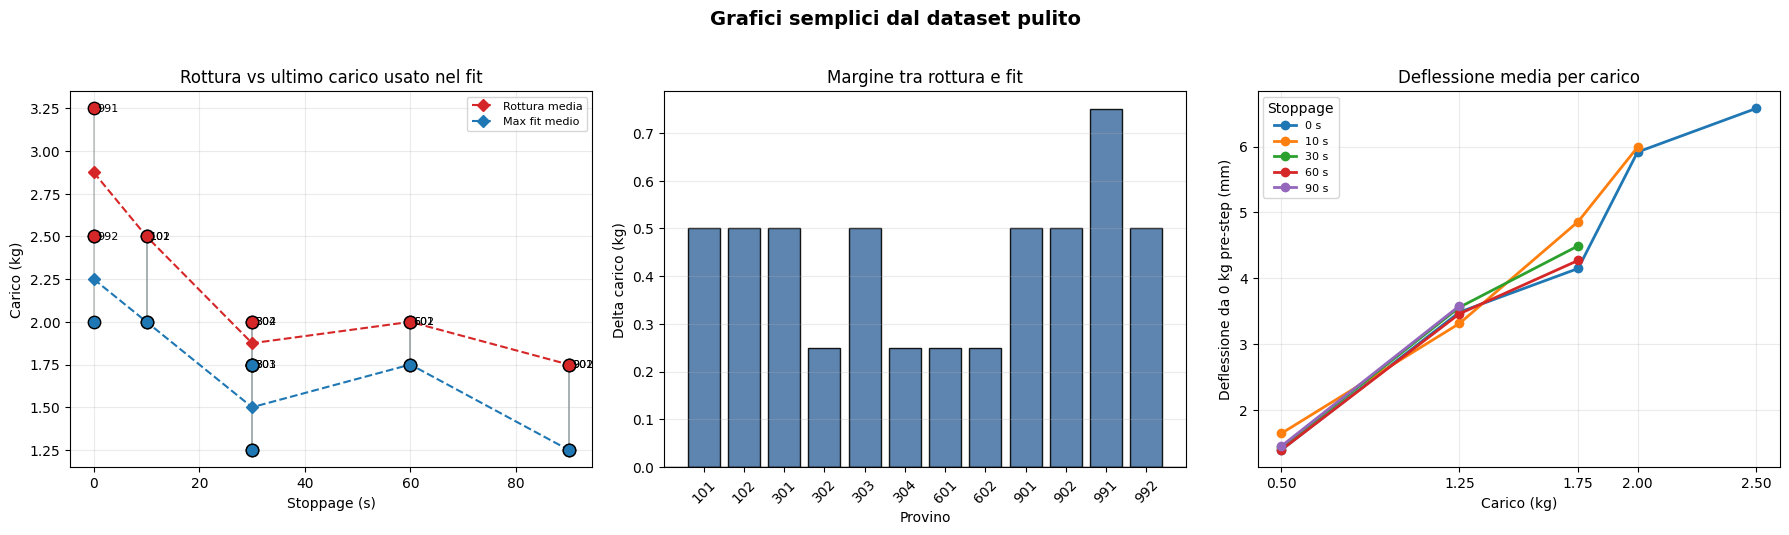

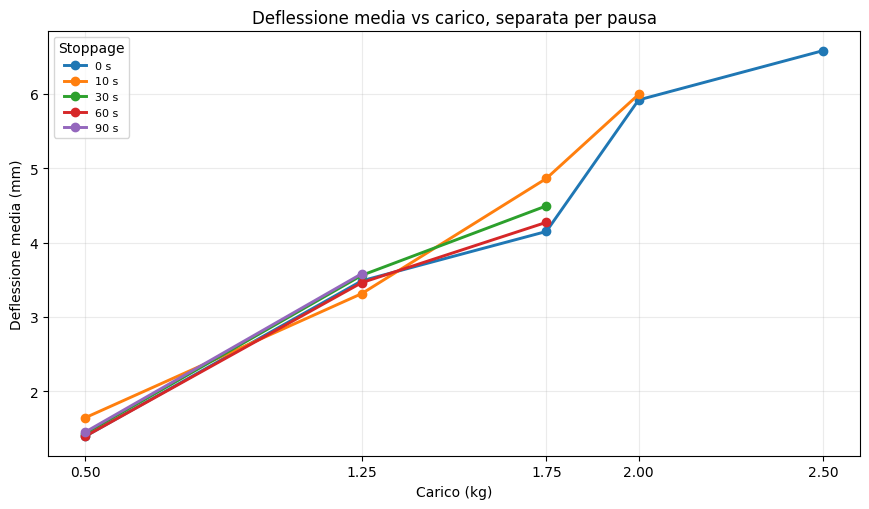

In [155]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

required_names = [
    'df_step_clean',
    'df_step_comparable',
    'df_specimen_clean',
    'df_plot_summary',
]
missing_names = [name for name in required_names if name not in globals()]
if missing_names:
    raise RuntimeError(f"Esegui prima la cella del dataset pulito. Nomi mancanti: {missing_names}")


def smooth_series(values, window=3):
    values = pd.Series(values).astype(float)
    return values.rolling(window=window, center=True, min_periods=1).mean()


df_focus = df_specimen_clean.copy()
df_focus['Delta rupture-fit load (kg)'] = df_focus['Confirmed load (kg)'] - df_focus['Max load used in fit (kg)']
df_focus['Rupture/fit ratio'] = df_focus['Confirmed load (kg)'] / df_focus['Max load used in fit (kg)']

df_step_good = df_step_comparable.copy()
if 'Deflection from pre-step 0 kg (mm)' not in df_step_good.columns:
    raise RuntimeError('df_step_comparable does not contain the expected column for simple plots.')

print('Simple summary of clean dataset:')
display(
    df_focus[[
        'Specimen',
        'Stoppage (s)',
        'Confirmed load (kg)',
        'Max load used in fit (kg)',
        'Delta rupture-fit load (kg)',
        'N step confrontabili',
        'Compliance C (mm/kg)',
        'Stiffness k (N/mm)',
    ]].sort_values(['Stoppage (s)', 'Specimen'])
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5.2))
ax1, ax2, ax3 = axes

# 1) Carico di rottura e massimo carico usato nel fit
for _, row in df_focus.iterrows():
    stop = row['Stoppage (s)']
    ax1.scatter(stop, row['Confirmed load (kg)'], color='#d62728', s=80, edgecolors='k', zorder=3)
    ax1.scatter(stop, row['Max load used in fit (kg)'], color='#1f77b4', s=80, edgecolors='k', zorder=3)
    ax1.plot([stop, stop], [row['Max load used in fit (kg)'], row['Confirmed load (kg)']], color='#7f8c8d', linewidth=1.2, alpha=0.5)
    ax1.text(stop + 0.6, row['Confirmed load (kg)'], row['Specimen'], fontsize=8, va='center')
mean_break = df_focus.groupby('Stoppage (s)', as_index=False)[['Confirmed load (kg)', 'Max load used in fit (kg)']].mean().sort_values('Stoppage (s)')
ax1.plot(mean_break['Stoppage (s)'], mean_break['Confirmed load (kg)'], color='#d62728', linestyle='--', marker='D', label='Rupture media')
ax1.plot(mean_break['Stoppage (s)'], mean_break['Max load used in fit (kg)'], color='#1f77b4', linestyle='--', marker='D', label='Max fit medio')
ax1.set_title('Rupture vs last load used in fit')
ax1.set_xlabel('Stoppage (s)')
ax1.set_ylabel('Load (kg)')
ax1.grid(True, alpha=0.25)
ax1.legend(fontsize=8)

# 2) Differenza tra rottura e ultimo carico usato nel fit
ax2.bar(df_focus['Specimen'], df_focus['Delta rupture-fit load (kg)'], color='#4c78a8', edgecolor='black', alpha=0.9)
ax2.axhline(0, color='black', linewidth=1)
ax2.set_title('Margin between rupture and fit')
ax2.set_xlabel('Specimen')
ax2.set_ylabel('Delta load (kg)')
ax2.tick_params(axis='x', rotation=45)
ax2.grid(True, axis='y', alpha=0.25)

# 3) Deflessione locale per carico, media per stoppage
for stop in sorted(df_step_good['Stoppage (s)'].dropna().unique()):
    grp = df_step_good[df_step_good['Stoppage (s)'] == stop].sort_values('Load (kg)')
    if grp.empty:
        continue
    mean_series = grp.groupby('Load (kg)', as_index=False)['Deflection from pre-step 0 kg (mm)'].mean().sort_values('Load (kg)')
    ax3.plot(
        mean_series['Load (kg)'],
        mean_series['Deflection from pre-step 0 kg (mm)'],
        marker='o', linewidth=2.0, label=f'{int(stop)} s'
    )
ax3.set_title('Mean deflection by load')
ax3.set_xlabel('Load (kg)')
ax3.set_ylabel('Deflection from pre-step 0 kg (mm)')
ax3.grid(True, alpha=0.25)
ax3.legend(title='Stoppage', fontsize=8)
ax3.set_xticks(sorted(df_step_good['Load (kg)'].dropna().unique()))

fig.suptitle('Grafici semplici dal dataset pulito', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


### 7.5 Correlation Stoppage Time ↔ Mechanical Behavior

During FFF 3D printing, the molten filament is deposited layer by layer. When the printing is **paused** for a certain time (the *pause* or *stoppage*), the already deposited material cools down. Upon restarting, the new molten filament bonds to a layer that has already cooled, creating a **weak interface** (artificial defect). The longer the pause, the colder the underlying layer, and the worse the interlayer adhesion.

In this section, we measure how this pause affects the behavior of the specimen under bending load. In particular, we analyze four aspects:

**1. Load-deflection curves by stoppage group**

For each specimen, increasing weights are applied during the test and the vertical deflection is measured. The load-deflection relationship is approximated by a straight line passing through the origin: its slope is the **compliance** $C$ (mm/kg), defined as:
$$C = rac{\Delta y}{\Delta P}$$
where $\Delta y$ is the vertical deflection (mm) and $\Delta P$ is the applied load (kg). A higher slope indicates a more compliant, thus weaker, specimen. By grouping the specimens by stoppage duration, we compare whether specimens with longer pauses show steeper (more compliant) curves.

**2. Global comparison of all specimens**

All load-deflection lines overlaid in a single plot, with colors associated with the stoppage duration. Allows visual evaluation of whether a systematic separation exists between the groups.

**3. Plastic deformation accumulation cycle by cycle (spaghetti plot)**

Each time a specimen is unloaded to $0$ kg after a load cycle $i$, we measure the *shift* relative to the initial position: this is the **accumulated plastic deformation** $\Delta y_{	ext{plastic}}^{(i)}$ measured in (mm):
$$\Delta y_{	ext{plastic}}^{(i)} = y_{0	ext{kg}}^{	ext{post-cycle}\ i} - y_{0	ext{kg}}^{	ext{initial}}$$
If the material were perfectly elastic, the shift would always be $0$. In reality, at each subsequent cycle, we expect the shift to increase (monotonically increasing curve), because each loading leaves a small additional permanent deformation. Specimens with longer pauses should accumulate plastic deformation faster because the weak interface yields sooner.

**4. Mean plastic shift at 0 kg vs stoppage**

Aggregated average of the plastic shift for each stoppage group, with error bars. Summarizes the trend observed in the spaghetti plot.

### 17. Damage vs Stoppage Time Correlation Plot

**Objective:** Plot graphs that directly correlate 3D printing pause time (Stoppage) with the measured performance (Stiffness, Elastic Modulus, Max Load).

**Output:** A 2x2 grid of bar and scatter plots (Boxplot/Scatter) generated with Matplotlib and Seaborn.

In [ ]:
# =============================================================================
# 7.5  GRAFICI: CURVE CARICO-DEFLESSIONE + DANNO PLASTICO vs PAUSA
# =============================================================================
import matplotlib.pyplot as plt
import numpy as np

# --- preparazione dati ---
df_corr = df_mech.copy()
df_corr['Stoppage (s)'] = df_corr['Specimen'].apply(
    lambda x: 0 if str(x).startswith('99') else int(str(x)[:2])
)
stoppage_order = sorted(df_corr['Stoppage (s)'].unique())

palette = {
    s: plt.cm.cividis(i / max(len(stoppage_order) - 1, 1))
    for i, s in enumerate(stoppage_order)
}

LINESTYLES = ['-', '--', '-.', ':', (0, (3, 1, 1, 1))]

# =====================================================================
# GRAFICO 1 — Curve Carico-Deflessione per gruppo di Pausa
# =====================================================================
n_groups = len(stoppage_order)
n_cols = min(3, n_groups)
n_rows = (n_groups + n_cols - 1) // n_cols
fig1, axes1 = plt.subplots(n_rows, n_cols, figsize=(5.5 * n_cols, 4.8 * n_rows), squeeze=False)

for idx, s in enumerate(stoppage_order):
    r, c = divmod(idx, n_cols)
    ax = axes1[r][c]
    pids_in_group = sorted(df_corr.loc[df_corr['Stoppage (s)'] == s, 'Specimen'].tolist())
    cm_sub = plt.cm.tab10

    for j, pid in enumerate(pids_in_group):
        if pid not in specimens_results:
            continue
        sr = specimens_results[pid]
        xp, yp = sr['x_pts'], sr['y_pts']
        if not xp:
            continue
        color = cm_sub(j / max(len(pids_in_group) - 1, 1))
        ls = LINESTYLES[j % len(LINESTYLES)]
        ax.scatter(xp, yp, color=color, s=50, edgecolors='k', linewidths=0.4, zorder=4)

        if sr['slope'] and np.isfinite(sr['slope']):
            x_line = np.linspace(0, max(xp) * 1.15, 50)
            ax.plot(x_line, sr['slope'] * x_line, color=color, linewidth=2.0,
                    linestyle=ls, label=f"{pid} (C={sr['slope']:.2f})")

    ax.set_title(f"Stoppage: {s} s", fontsize=11, fontweight='bold')
    ax.set_xlabel('Load (kg)')
    ax.set_ylabel('Net deflection (mm)')
    ax.grid(True, alpha=0.25, linestyle='--')
    ax.legend(fontsize=8, loc='upper left')
    ax.set_xlim(left=0)
    ax.set_ylim(bottom=0)

for idx in range(n_groups, n_rows * n_cols):
    r, c = divmod(idx, n_cols)
    axes1[r][c].set_visible(False)

fig1.suptitle('Load-Deflection Curves by Stoppage Group', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# =====================================================================
# GRAFICO 2 — Tutte le curve carico-deflessione in un unico grafico
# =====================================================================
fig2, ax2 = plt.subplots(figsize=(10, 6.5))

all_pids = sorted(specimens_results.keys())
legend_entries = {}

for pid in all_pids:
    sr = specimens_results[pid]
    xp, yp = sr['x_pts'], sr['y_pts']
    if not xp or not sr['slope'] or not np.isfinite(sr['slope']):
        continue

    s = 0 if str(pid).startswith('99') else int(str(pid)[:2])
    color = palette.get(s, 'gray')

    ax2.scatter(xp, yp, color=color, s=55, edgecolors='k', linewidths=0.4, zorder=4, alpha=0.8)

    x_line = np.linspace(0, max(xp) * 1.15, 50)
    line, = ax2.plot(x_line, sr['slope'] * x_line, color=color, linewidth=1.6, alpha=0.75)

    ax2.annotate(
        pid,
        xy=(max(xp) * 1.05, sr['slope'] * max(xp) * 1.05),
        fontsize=7.5, color=color, fontweight='bold', va='center',
    )

    if s not in legend_entries:
        legend_entries[s] = line

handles = [legend_entries[s] for s in sorted(legend_entries.keys())]
labels = [f'Stoppage {s} s' for s in sorted(legend_entries.keys())]
ax2.legend(handles, labels, fontsize=9, title='Stoppage group', title_fontsize=10, loc='upper left')

ax2.set_xlabel('Load (kg)', fontsize=12)
ax2.set_ylabel('Net deflection (mm)', fontsize=12)
ax2.set_title('Global Comparison: Bending Curves of All Specimens', fontsize=14, fontweight='bold')
ax2.set_xlim(left=0)
ax2.set_ylim(bottom=0)
ax2.grid(True, alpha=0.25, linestyle='--')
plt.tight_layout()
plt.show()

# =====================================================================
# GRAFICO 3 — Spaghetti Plot: deformazione plastica accumulata
# =====================================================================
if 'df_step_comparable' in dir() and not df_step_comparable.empty:
    fig3, ax3 = plt.subplots(figsize=(10, 6))

    all_pids_sorted = sorted(df_step_comparable['Specimen'].unique())

    for pid in all_pids_sorted:
        s = 0 if str(pid).startswith('99') else int(str(pid)[:2])
        color = palette.get(s, 'gray')

        df_pid = df_step_comparable[df_step_comparable['Specimen'] == pid].sort_values('Segment')
        shifts = df_pid['0 kg shift vs initial (mm)'].dropna().values

        if len(shifts) == 0:
            continue

        cycles = np.arange(1, len(shifts) + 1)

        ax3.plot(
            cycles, shifts,
            marker='o', linewidth=2.0, markersize=6,
            color=color, alpha=0.8,
            label=f"{pid} ({s}s)",
        )
        # etichetta a fine riga
        ax3.annotate(
            pid, xy=(cycles[-1] + 0.15, shifts[-1]),
            fontsize=8, color=color, fontweight='bold', va='center',
        )

    ax3.set_xlabel('Unload cycle to 0 kg', fontsize=12)
    ax3.set_ylabel('Accumulated plastic deformation (mm)', fontsize=12)
    ax3.set_title(
        'Accumulo di Deformazione Plastica: Shift a 0 kg Ciclo per Ciclo',
        fontsize=13, fontweight='bold',
    )
    ax3.set_xticks(range(1, int(ax3.get_xlim()[1]) + 1))
    ax3.grid(True, alpha=0.25, linestyle='--')

    # legenda per gruppo di pausa
    legend_handles = []
    for s in stoppage_order:
        pids_with_data = [
            p for p in all_pids_sorted
            if (0 if str(p).startswith('99') else int(str(p)[:2])) == s
        ]
        if pids_with_data:
            from matplotlib.lines import Line2D
            legend_handles.append(
                Line2D([0], [0], color=palette[s], linewidth=2.5, label=f'Stoppage {s} s')
            )
    ax3.legend(handles=legend_handles, fontsize=9, title='Gruppo', title_fontsize=10, loc='upper left')

    plt.tight_layout()
    plt.show()
else:
    print("⚠️ df_step_comparable non disponibile, spaghetti plot saltato.")

# =====================================================================
# GRAFICO 4 — Shift Plastico medio a 0 kg vs Pausa
# =====================================================================
if 'df_step_comparable' in dir() and not df_step_comparable.empty:
    metric = '0 kg shift vs initial (mm)'
    df_tmp = df_step_comparable.copy()
    if 'Stoppage (s)' not in df_tmp.columns:
        df_tmp['Stoppage (s)'] = df_tmp['Specimen'].apply(
            lambda x: 0 if str(x).startswith('99') else int(str(x)[:2])
        )

    fig4, ax4 = plt.subplots(figsize=(9, 5.5))
    means, stds, xs = [], [], []

    for s in stoppage_order:
        vals = df_tmp.loc[df_tmp['Stoppage (s)'] == s, metric].dropna()
        if len(vals) == 0:
            continue
        xs.append(s)
        means.append(vals.mean())
        stds.append(vals.std() if len(vals) > 1 else 0)

        jitter = np.random.default_rng(11).uniform(-1.5, 1.5, size=len(vals))
        ax4.scatter(
            [s] * len(vals) + jitter, vals,
            color=palette.get(s, 'gray'), edgecolors='k', s=45, alpha=0.55, zorder=3,
        )

    ax4.bar(
        xs, means, yerr=stds, width=6,
        capsize=4, color=[(*palette.get(s, (0.5, 0.5, 0.5))[:3], 0.35) for s in xs],
        edgecolor='black', linewidth=0.7, zorder=2,
    )
    ax4.errorbar(xs, means, yerr=stds, fmt='D', color='black', markersize=6, capsize=4, zorder=5)

    ax4.set_xlabel('Stoppage duration (s)', fontsize=11)
    ax4.set_ylabel('0 kg shift vs initial position (mm)', fontsize=11)
    ax4.set_title('Residual Plastic Deformation (Shift at 0 kg) vs Stoppage Duration', fontsize=13, fontweight='bold')
    ax4.set_xticks(stoppage_order)
    ax4.set_xticklabels([f'{s} s' for s in stoppage_order])
    ax4.grid(True, alpha=0.25, linestyle='--')
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ df_step_comparable non disponibile, grafico shift plastico saltato.")

print("\n✅ Section 7.5 completed: 4 plots.")


### 18. Interactive Table of Mechanical Parameters

**Objective:** Provide the user with a complete summary DataFrame, in a navigable table format, with all the metrics deduced from the video analysis.

**Output:** Interactive Pandas (HTML) table supporting scrolling, filters, and sorting.

In [149]:
import ipywidgets as widgets
from IPython.display import display, clear_output

# Usiamo il dataset arricchito (una riga per provino, con tutte le metriche)
if 'df_specimen_clean' not in globals():
    raise RuntimeError("Esegui prima le celle di costruzione del dataset (Sezione 7+).")

cols_visual = [
    'Specimen',
    'Stoppage (s)',
    'Confirmed load (kg)',
    'Max load used in fit (kg)',
    'N step confrontabili',
    'Compliance C (mm/kg)',
    'Stiffness k (N/mm)',
    'E_bending (GPa)',
    'Max bending stress (MPa)',
    'Breaking step load (kg)',
    'Last comparable damage index',
    'Linear R²',
    'Fit RMSE (mm)',
    'Truncated rupture',
    'Deflection area (mm*frame)',
]
available_cols = [c for c in cols_visual if c in df_specimen_clean.columns]
df_visual = df_specimen_clean[available_cols].copy()


def aggiorna_tabella(ordina_per, filtra_per):
    clear_output(wait=True)
    df_filtered = df_visual.copy()

    if filtra_per != 'All':
        val_stoppage = int(filtra_per.replace('s', ''))
        df_filtered = df_filtered[df_filtered['Stoppage (s)'] == val_stoppage]

    if ordina_per == 'Stiffness (Descending)':
        df_filtered = df_filtered.sort_values(by='Stiffness k (N/mm)', ascending=False)
    elif ordina_per == 'Stiffness (Ascending)':
        df_filtered = df_filtered.sort_values(by='Stiffness k (N/mm)', ascending=True)
    elif ordina_per == 'Stoppage (Ascending)':
        df_filtered = df_filtered.sort_values(by='Stoppage (s)', ascending=True)
    elif ordina_per == 'Linear R² (Descending)':
        df_filtered = df_filtered.sort_values(by='Linear R²', ascending=False)
    elif ordina_per == 'Breaking load (Descending)':
        df_filtered = df_filtered.sort_values(by='Confirmed load (kg)', ascending=False)
    elif ordina_per == 'Deflection area (Descending)':
        df_filtered = df_filtered.sort_values(by='Deflection area (mm*frame)', ascending=False)
    elif ordina_per == 'Fit quality (RMSE ascending)':
        df_filtered = df_filtered.sort_values(by='Fit RMSE (mm)', ascending=True)

    # Formattazione solo per le colonne effettivamente presenti
    fmt_map = {
        'Confirmed load (kg)': '{:.2f}',
        'Max load used in fit (kg)': '{:.2f}',
        'Breaking step load (kg)': '{:.2f}',
        'Compliance C (mm/kg)': '{:.4f}',
        'Stiffness k (N/mm)': '{:.2f}',
        'E_bending (GPa)': '{:.2f}',
        'Max bending stress (MPa)': '{:.2f}',
        'Last comparable damage index': '{:.3f}',
        'Linear R²': '{:.4f}',
        'Fit RMSE (mm)': '{:.3f}',
        'Deflection area (mm*frame)': '{:.0f}',
    }
    fmt = {col: f for col, f in fmt_map.items() if col in df_filtered.columns}

    gradient_cols = [
        c for c in ['Stiffness k (N/mm)', 'E_bending (GPa)', 'Confirmed load (kg)']
        if c in df_filtered.columns
    ]

    style_dict = df_filtered.style.format(fmt)
    if gradient_cols:
        style_dict = style_dict.background_gradient(cmap='plasma_r', subset=gradient_cols)
    style_dict = style_dict.set_properties(**{
        'text-align': 'center',
        'font-family': 'DejaVu Sans, Arial, Helvetica, sans-serif',
        'border': '1px solid #ccc'
    })

    print(f"Results filtered by: {filtra_per} | Sorted by: {ordina_per}\n")
    display(style_dict)


dropdown_ordina = widgets.Dropdown(
    options=[
        'None (Default)',
        'Stiffness (Descending)',
        'Stiffness (Ascending)',
        'Breaking load (Descending)',
        'Fit quality (RMSE ascending)',
        'Stoppage (Ascending)',
        'Linear R² (Descending)',
        'Deflection area (Descending)',
    ],
    value='None (Default)',
    description='Sort by:'
)

dropdown_filtra = widgets.Dropdown(
    options=['All', '0s', '10s', '30s', '60s', '90s'],
    value='All',
    description='Stoppage:'
)

ui = widgets.HBox([dropdown_ordina, dropdown_filtra])
out = widgets.interactive_output(aggiorna_tabella, {
    'ordina_per': dropdown_ordina,
    'filtra_per': dropdown_filtra
})

display(ui, out)

Output()

### 7.6 Cumulative Deformation-Time Area

This section extracts, for each specimen, the **cumulative deformation work curve** over time.

The area under the deflection curve $d(t) = y(t) - y_0$ represents an integral over time of the deformation, which in literature is correlated with the energy dissipated by viscous deformation and damage, and is therefore an energy proxy measurable also thermally.

**How to read the plot:**
- On the **X-axis**, the applied load (kg) at the end of each step.
- On the **Y-axis**, the cumulative area $\int_0^{t_{	ext{step}}} d(t)\,dt$ calculated in `mm·s`.
- Each line represents a specimen; the marker indicates the rupture point.
- A defective specimen (high *stoppage*) accumulates area faster at the same load due to creep and premature layer interface damage.

The **interactive widget** shows, for the selected specimen, the time curve with the under-curve area highlighted in transparency.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import ipywidgets as widgets
from IPython.display import display, clear_output
import pandas as pd

# ───────────────────────────────────────────────────────────────────────────────
# Parametri fissi
# ───────────────────────────────────────────────────────────────────────────────
FPS = 30.0          # frame al secondo
DT  = 1.0 / FPS    # durata di un frame in secondi

# ───────────────────────────────────────────────────────────────────────────────
# 1. Calcolo df_cumulative_area
# ───────────────────────────────────────────────────────────────────────────────
if 'df_step_clean' not in globals() or 'dati_tracking' not in globals():
    raise RuntimeError("Run the previous sections first to get df_step_clean and dati_tracking.")

cumulative_rows = []

for pid, grp in df_step_clean.groupby('Specimen'):
    pid_str = str(pid)
    if pid_str not in dati_tracking:
        continue

    y_raw    = np.asarray(dati_tracking[pid_str]['spostamento'], dtype=float)
    n_frames = len(y_raw)

    # Spostamento 0 kg iniziale di riferimento
    y0 = float(grp['Initial 0 kg displacement (mm)'].iloc[0])

    # Calcoliamo la deflessione imponendo a zero l'area di rimbalzo negativa
    deflection = np.maximum(y_raw - y0, 0.0)
    
    # Integrale cumulativo frame-per-frame (trapezoide)
    cum_integral = np.cumsum(deflection) * DT   # mm·s

    # Stoppage del provino
    try:
        stoppage_s = int(grp['Stoppage (s)'].iloc[0])
    except (ValueError, TypeError):
        stoppage_s = -1

    # Filtriamo e tracciamo solo i carichi crescenti progressivi per evitare
    # zig-zag o decrescite fittizie causate dai gradini intermedi di ricarico a 0.5 kg.
    max_load_so_far = -1.0
    grp_sorted = grp.sort_values('Segment')

    for _, row in grp_sorted.iterrows():
        load = float(row['Load (kg)'])
        if load <= max_load_so_far:
            # Salta i gradini di ricarico intermedi per mantenere la curva cumulativa monotona
            continue
        max_load_so_far = load

        is_comparable = bool(row['Comparable step'])
        if is_comparable:
            y_post_zero = float(row['0 kg post-step displacement (mm)'])
            
            # Integriamo fino a quando la deformazione non torna entro y_post_zero + 0.5 mm dallo scarico
            frame_end = int(row['Frame end'])
            while frame_end < n_frames and y_raw[frame_end] > y_post_zero + 0.5:
                frame_end += 1
                
            # Evita di sforare nel segmento successivo
            next_rows = grp_sorted[grp_sorted['Frame start'] > row['Frame end']].sort_values('Frame start')
            if not next_rows.empty:
                max_frame = int(next_rows.iloc[0]['Frame start'])
                frame_end = min(frame_end, max_frame)
        else:
            # È lo step di rottura
            frame_end = int(min(row['Frame end'], n_frames - 1))

        cumulative_rows.append({
            'Specimen':             pid_str,
            'Stoppage (s)':        stoppage_s,
            'Load (kg)':         load,
            'Frame end step':      frame_end,
            'Step end time (s)': frame_end * DT,
            'Cumulative Area (mm·s)': float(cum_integral[frame_end]),
        })

df_cumulative_area = pd.DataFrame(cumulative_rows)

# Area totale a rottura (ultimo valore cumulativo per provino)
df_area_at_break = (
    df_cumulative_area
    .sort_values('Frame end step')
    .groupby('Specimen', as_index=False)
    .last()
    [['Specimen', 'Stoppage (s)', 'Load (kg)', 'Cumulative Area (mm·s)']]
    .rename(columns={
        'Load (kg)':           'Breaking load (kg)',
        'Cumulative Area (mm·s)':  'Total Area at Rupture (mm·s)',
    })
    .sort_values(['Stoppage (s)', 'Specimen'])
    .reset_index(drop=True)
)

print(f"df_cumulative_area built: {len(df_cumulative_area)} righe, "
      f"{df_cumulative_area['Specimen'].nunique()} provini.")

# ───────────────────────────────────────────────────────────────────────────────
# 2. Grafico globale: Carico vs Area Cumulata (tutti i specimens)
# ───────────────────────────────────────────────────────────────────────────────
ALL_PIDS = sorted(df_cumulative_area['Specimen'].unique())
CMAP     = cm.get_cmap('tab20', len(ALL_PIDS))
PID_COLOR = {pid: CMAP(idx) for idx, pid in enumerate(ALL_PIDS)}

LINE_STYLES = ['-', '--', ':', '-.']

fig, ax = plt.subplots(figsize=(13, 6))

for pid, grp_p in df_cumulative_area.groupby('Specimen'):
    grp_p = grp_p.sort_values('Load (kg)')
    stop   = int(grp_p['Stoppage (s)'].iloc[0])
    color  = PID_COLOR[pid]

    # Scegli un line style per distinguere provini con stesso stoppage
    pids_same = sorted(df_cumulative_area[df_cumulative_area['Stoppage (s)'] == stop]['Specimen'].unique())
    ls_idx    = pids_same.index(pid) % len(LINE_STYLES)

    ax.plot(
        grp_p['Load (kg)'],
        grp_p['Cumulative Area (mm·s)'],
        marker='o', markersize=5,
        color=color, linestyle=LINE_STYLES[ls_idx],
        linewidth=1.8, label=f"{pid} ({stop}s)",
    )
    # Marker di rottura (ultimo punto)
    ax.scatter(
        grp_p['Load (kg)'].iloc[-1],
        grp_p['Cumulative Area (mm·s)'].iloc[-1],
        color=color, marker='X', s=120, zorder=5,
    )

ax.set_xlabel('Applied load (kg)', fontsize=12)
ax.set_ylabel('Cumulative Area  ∫d(t)dt  (mm·s)', fontsize=12)
ax.set_title('Cumulative Deflection Area for Progressive Load Step\n'
             'Marker ✕ = rupture point', fontsize=13)
ax.legend(title='Specimen (Stoppage)', bbox_to_anchor=(1.01, 1), loc='upper left',
          fontsize=8, ncol=1)
ax.grid(True, alpha=0.25, linestyle='--')
plt.tight_layout()
plt.show()

# Tabella riassuntiva area a rottura
print("\nTotal Area at Rupture per specimen:")
display(
    df_area_at_break.style.format({
        'Breaking load (kg)':       '{:.2f}',
        'Total Area at Rupture (mm·s)': '{:.1f}',
    }).background_gradient(cmap='plasma_r', subset=['Total Area at Rupture (mm·s)'])
    .set_properties(**{'text-align': 'center'})
)

# ───────────────────────────────────────────────────────────────────────────────
# 3. Widget interattivo: area sottesa per il singolo provino
# ───────────────────────────────────────────────────────────────────────────────
ALL_PIDS = sorted(df_cumulative_area['Specimen'].unique())


def plot_area_single(provino):
    clear_output(wait=True)

    if provino not in dati_tracking:
        print(f"⚠️ Dati tracking non disponibili per {provino}.")
        return

    y_raw    = np.asarray(dati_tracking[provino]['spostamento'], dtype=float)
    n_frames = len(y_raw)

    grp_pid  = df_step_clean[df_step_clean['Specimen'].astype(str) == str(provino)]
    y0 = float(grp_pid['Initial 0 kg displacement (mm)'].iloc[0])

    deflection  = np.maximum(y_raw - y0, 0.0)
    t_seconds   = np.arange(n_frames) * DT

    # Frame di fine dell'ultimo step (rottura)
    load_segs = grp_pid[grp_pid['Load (kg)'] > 0].sort_values('Frame end')
    if load_segs.empty:
        print(f"⚠️ Nessun segmento di carico trovato per {provino}.")
        return

    frame_break = int(min(load_segs['Frame end'].iloc[-1], n_frames - 1))
    area_total  = float(np.sum(deflection[:frame_break + 1]) * DT)

    # Colori e stoppage
    try:
        stop = int(grp_pid['Stoppage (s)'].iloc[0])
    except (ValueError, TypeError):
        stop = -1
    color = PID_COLOR.get(provino, 'steelblue')

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # ── Pannello sinistro: serie temporale con area shaded ──────────────────
    ax1 = axes[0]
    t_plot = t_seconds[:frame_break + 1]
    d_plot = deflection[:frame_break + 1]

    ax1.plot(t_plot, d_plot, color=color, linewidth=1.5, zorder=3)
    ax1.fill_between(t_plot, 0, d_plot,
                     where=(d_plot > 0),
                     alpha=0.25, color=color, label='Deflection area')

    # Marker fine di ogni step (inclusa la fase di scarico)
    max_l = -1.0
    for _, row in load_segs.sort_values('Segment').iterrows():
        load = float(row['Load (kg)'])
        if load <= max_l:
            continue
        max_l = load

        is_comparable = bool(row['Comparable step'])
        if is_comparable:
            y_post_zero = float(row['0 kg post-step displacement (mm)'])
            fe = int(row['Frame end'])
            while fe < n_frames and y_raw[fe] > y_post_zero + 0.5:
                fe += 1
            next_rows = load_segs[load_segs['Frame start'] > row['Frame end']].sort_values('Frame start')
            if not next_rows.empty:
                max_frame = int(next_rows.iloc[0]['Frame start'])
                fe = min(fe, max_frame)
        else:
            fe = int(min(row['Frame end'], n_frames - 1))

        ax1.axvline(fe * DT, color='black', linestyle=':', linewidth=0.8, alpha=0.5)
        ax1.annotate(f"{load}kg",
                     xy=(fe * DT, deflection[fe]),
                     xytext=(3, 6), textcoords='offset points',
                     fontsize=7, color='black', alpha=0.7)

    ax1.axhline(0, color='black', linewidth=0.8, alpha=0.4)
    ax1.set_xlabel('Time (s)', fontsize=11)
    ax1.set_ylabel('Deflection d(t) = max(y(t) − y₀, 0)  (mm)', fontsize=11)
    ax1.set_title(f'Specimen {provino} — Stoppage {stop}s\n'
                  f'Area Totale a Rupture = {area_total:.1f} mm·s', fontsize=12)
    ax1.legend(fontsize=9)
    ax1.grid(True, alpha=0.2, linestyle='--')

    # ── Pannello destro: curva cumulativa (Carico vs Area) ──────────────────
    ax2 = axes[1]
    grp_cum = (
        df_cumulative_area[df_cumulative_area['Specimen'] == provino]
        .sort_values('Load (kg)')
    )
    ax2.plot(grp_cum['Load (kg)'], grp_cum['Cumulative Area (mm·s)'],
             marker='o', color=color, linewidth=2, markersize=7)
    ax2.scatter(grp_cum['Load (kg)'].iloc[-1],
                grp_cum['Cumulative Area (mm·s)'].iloc[-1],
                color='red', marker='X', s=150, zorder=5, label='Rupture')

    for _, row in grp_cum.iterrows():
        ax2.annotate(f"{row['Load (kg)']}kg",
                     xy=(row['Load (kg)'], row['Cumulative Area (mm·s)']),
                     xytext=(4, 4), textcoords='offset points', fontsize=8)

    ax2.set_xlabel('Applied load (kg)', fontsize=11)
    ax2.set_ylabel('Cumulative Area  ∫d(t)dt  (mm·s)', fontsize=11)
    ax2.set_title(f'Curva Cumulativa — Specimen {provino}', fontsize=12)
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.2, linestyle='--')

    plt.tight_layout()
    plt.show()

    # Tabella step del provino selezionato
    display(
        grp_cum[['Load (kg)', 'Step end time (s)', 'Cumulative Area (mm·s)']]
        .style.format({
            'Load (kg)':           '{:.2f}',
            'Step end time (s)':   '{:.1f}',
            'Cumulative Area (mm·s)':  '{:.2f}',
        })
        .set_properties(**{'text-align': 'center'})
    )


dropdown_pid = widgets.Dropdown(
    options=ALL_PIDS,
    value=ALL_PIDS[0],
    description='Specimen:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='250px'),
)

out_widget = widgets.interactive_output(plot_area_single, {'provino': dropdown_pid})
display(widgets.VBox([
    widgets.HTML('<b style="font-size:14px">Under-Curve Area Visualization — Single Specimen</b>'),
    dropdown_pid,
    out_widget,
]))

print("\n✅ Section 7.6 completed.")


### 19. Final Dataset Export

**Objective:** Physically save the final analysis results on disk (in CSV format): mechanical properties, elongation table, and load verification diagnostics, for training ML models.

**Output:** Creation of the `dati/dataset_finale/meccanica` directory and textual confirmation of the CSV files saved.

In [154]:
import os
import pandas as pd

EXPORT_DIR = os.path.join('dati', 'dataset_finale', 'meccanica')
os.makedirs(EXPORT_DIR, exist_ok=True)

# Verify requirements
clean_required = ['df_step_clean', 'df_specimen_clean']
missing_clean = [name for name in clean_required if name not in globals()]
if missing_clean:
    raise RuntimeError(f'Run previous cells first. Missing: {missing_clean}')

# 1. Specimen Macroscopic Summary
# Extracted from df_specimen_clean which contains all verified loads, max areas, and moduli.
df_export_specimen = df_specimen_clean.copy()
df_export_specimen.to_csv(os.path.join(EXPORT_DIR, '1_Specimen_Macroscopic_Summary.csv'), index=False)
print(f'✅ Saved 1_Specimen_Macroscopic_Summary.csv ({len(df_export_specimen)} rows)')

# 2. Load Step Progression
# Extracted from df_step_clean which contains step-by-step deflection, area, and cumulative area.
df_export_steps = df_step_clean.copy()
# Optional: sort by specimen and load for clean timeline
if 'Specimen' in df_export_steps.columns and 'Load (kg)' in df_export_steps.columns:
    df_export_steps = df_export_steps.sort_values(by=['Specimen', 'Load (kg)']).reset_index(drop=True)
df_export_steps.to_csv(os.path.join(EXPORT_DIR, '2_Load_Step_Progression.csv'), index=False)
print(f'✅ Saved 2_Load_Step_Progression.csv ({len(df_export_steps)} rows)')

print(f'\n🎉 Export completed successfully in: {EXPORT_DIR}')
print('The dataset is now clean, concise, and ready for correlation with thermal videos.')


Salvato mechanical_properties.csv (12 righe)
Salvato elongation_table.csv (64 righe)
Salvato clean_step_dataset.csv (64 righe)
Salvato clean_comparable_steps.csv (45 righe)
Salvato clean_specimen_dataset.csv (12 righe)
Salvato clean_plot_summary.csv (17 righe)
Salvato load_verification.csv (12 righe)

Export meccanica completato in: dati/dataset_finale/meccanica
